<a href="https://colab.research.google.com/github/jordi-cx/it_academy/blob/main/sprint_09_jcx_wip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 9: Visualización de Datos con Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px

## Conexión a BigQuery para obtener los Datos

Voy a usar las tablas de datos (actualizadas) que teníamos en BigQuery, y las guardo en dataframes

*(df_transactions, df_products, df_companies, df_users, df_ccards)*

In [2]:
# Conexión a BigQuery
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
project_id = 'sprint9-visuals-jordi-calmet'
client = bigquery.Client(project=project_id)

In [3]:
# Tabla de Transacciones
sql_query = """
SELECT * FROM `sprint9-visuals-jordi-calmet.sprint9_analytics.transactions_clean`
"""

df_transactions = client.query(sql_query).result().to_dataframe()
df_transactions.head()

,transaction_id,card_id,business_id,transaction_time,amount,declined,product_ids,user_id,latitude,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,CcS-4857,b-2378,2022-09-21 22:52:27+00:00,328.77,0,"28, 8, 73",276,40.513745,-4.238857,2.19,57.06,0.00,online,NO_CAMPAIGN,desktop,0,None,46.53
1,6BE556F4-9B3F-4C64-A4E2-237E89269A33,CcS-4857,b-2442,2022-05-20 08:36:18+00:00,767.03,0,"14, 39, 65, 27",276,40.031749,-4.169403,5.11,133.12,0.00,online,NO_CAMPAIGN,desktop,0,None,58.27
2,2C8531E2-AB1C-456F-9A87-BC9390E6AA8C,CcS-4857,b-2466,2021-01-18 20:41:16+00:00,579.65,0,"61, 18, 17, 58, 42",276,40.886042,-3.677155,3.86,100.60,0.00,online,NO_CAMPAIGN,desktop,0,None,52.23
3,B954A0B3-9314-4615-ACBB-B31E0245D8D1,CcS-4857,b-2558,2024-10-07 16:43:17+00:00,133.63,0,35,276,40.305523,-3.744586,0.86,22.33,4.99,marketplace,NO_CAMPAIGN,desktop,0,None,12.85
4,FD857386-28F9-49DE-8F32-E2458CDE1752,CcS-4857,b-2434,2024-01-15 20:18:34+00:00,250.61,0,"48, 54, 23",276,40.961108,-3.961454,1.64,42.63,4.99,online,NO_CAMPAIGN,desktop,0,None,64.30


In [4]:
# Tabla de Productos
sql_query = """
SELECT * FROM `sprint9-visuals-jordi-calmet.sprint9_analytics.products_clean`
"""

df_products = client.query(sql_query).result().to_dataframe()
df_products.head()

,product_id,name,price,color,weight,warehouse_id,category,brand,cost,launch_date
0,48,rock Renly in,21.53,#9e9e9e,2.1,43,Beauty,Bloom,7.38,2014-07-24
1,90,Winterfell,39.73,#757575,0.8,85,Beauty,CareLab,16.58,2013-11-01
2,97,jinn Winterfell,65.25,#bababa,1.0,92,Beauty,CareLab,26.25,2013-02-22
3,96,dooku solo,20.92,#282828,2.1,91,Beauty,CareLab,8.75,2013-09-21
4,18,Karstark warden,148.91,#c4c4c4,0.8,13,Beauty,CareLab,47.62,2013-07-11


In [5]:
# Tabla de Empresas
sql_query = """
SELECT * FROM `sprint9-visuals-jordi-calmet.sprint9_analytics.companies_clean`
"""

df_companies = client.query(sql_query).result().to_dataframe()
df_companies.head()

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2534,Mattis Foundation,+3 772 789 1009,sed@google.couk,Australia,https://www.mattis-foundation.com,Toys,budget
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2590,Euismod Mauris Institute,+18 395 939 7943,vivamus.molestie@icloud.ca,Belgium,https://www.euismod-mauris-institute.com,Food,budget
3,b-2314,A Institute,+47 306 328 7996,metus.aliquam@google.edu,Belgium,https://www.a-institute.com,Home,budget
4,b-2598,Aliquam Iaculis Lacus Corp.,+23 674 242 3712,dictum@aol.org,Belgium,https://www.aliquam-iaculis-lacus-corp.com,Fashion,budget


In [6]:
# Tabla de Usuarios
sql_query = """
SELECT * FROM `sprint9-visuals-jordi-calmet.sprint9_analytics.users_all_clean`
"""

df_users = client.query(sql_query).result().to_dataframe()
df_users.head()

,user_id,name,surname,phone,email,birth_date,country,city,postal_code,address,region,signup_date,user_segment,income_band
0,773,Nbmers,Igswliht,+33-938-8850,nbmers.igswliht@example.com,1960-10-19,Poland,Warsaw,00-001,666 Igswliht St,Europe,2013-03-06,established,high
1,1952,Drbbrl,Mwbvcqyd,+30-211-8955,drbbrl.mwbvcqyd@example.com,1956-11-23,Poland,Warsaw,00-001,802 Mwbvcqyd St,Europe,2017-04-22,established,medium
2,659,Imwaul,Qrcmepru,+46-231-2086,imwaul.qrcmepru@example.com,1958-06-15,Poland,Warsaw,00-001,490 Qrcmepru St,Europe,2013-08-09,established,medium
3,516,Mxbohk,Jkslfysn,+51-401-2493,mxbohk.jkslfysn@example.com,1951-08-11,Poland,Warsaw,00-001,538 Jkslfysn St,Europe,2015-01-12,established,medium
4,2485,Htuios,Ihbtrhtt,+43-811-8388,htuios.ihbtrhtt@example.com,1960-08-27,Poland,Warsaw,00-001,329 Ihbtrhtt St,Europe,2013-07-06,established,medium


In [7]:
# Tabla de Credit Cards
# sql_query = """
# SELECT * FROM `sprint9-visuals-jordi-calmet.sprint9_analytics.credit_cards_clean`
# """

df_ccards = client.query(sql_query).result().to_dataframe()
df_ccards.head()

,card_id,user_id,iban,pan,pin,cvv,track1,track2,expiring_date,card_type,card_renewal_flag
0,CcU-3106,251,CA617314077203880656677913,349547146395283,9733,209,%B1491494879325988^FhfgvwhNxaoik^7001543563?4,%B9821795210722817=03037207?7,2028-01-24,credit,1
1,CcS-8276,3695,FR913916486132911752724009,2847076749424490,2082,834,%B2847076749424490^RBEHOLRBEHOL^28080000000000...,%B2847076749424490=3312101629613334?,2028-01-25,credit,1
2,CcS-9430,4849,NL777402427450755133624260,1118341498825636,7164,742,%B1118341498825636^IZPYDIIZPYDI^22040000000000...,%B1118341498825636=2210101922076144?,2028-01-25,credit,1
3,CcS-8337,3756,PL740724627785179181620762,9734165269407010,4883,380,%B9734165269407010^NCVFQWNCVFQW^26100000000000...,%B9734165269407010=3105101125175929?,2028-01-25,credit,1
4,CcS-5461,880,DE195355302961354548130605,4657213720462543,1196,798,%B4657213720462543^NFAODBNFAODB^34030000000000...,%B4657213720462543=3110101469626048?,2028-01-25,credit,1


In [ ]:
# display(df_transactions.info())
# display(df_products.info())
# display(df_companies.info())
# display(df_users.info())
# display(df_ccards.info())

In [8]:
df_transactions['transaction_time'] = df_transactions['transaction_time'].dt.tz_localize(None).astype('datetime64[ns]')
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 non-null  object        
 1   card_id           100000 non-null  object        
 2   business_id       100000 non-null  object        
 3   transaction_time  100000 non-null  datetime64[ns]
 4   amount            100000 non-null  float64       
 5   declined          100000 non-null  Int64         
 6   product_ids       100000 non-null  object        
 7   user_id           100000 non-null  Int64         
 8   latitude          100000 non-null  float64       
 9   longitude         100000 non-null  float64       
 10  discount_amount   100000 non-null  float64       
 11  tax_amount        100000 non-null  float64       
 12  shipping_amount   100000 non-null  float64       
 13  channel           100000 non-null  object        
 14  campa

In [ ]:
display(df_companies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   company_id               100 non-null    object
 1   company_name             100 non-null    object
 2   phone                    100 non-null    object
 3   email                    100 non-null    object
 4   country                  100 non-null    object
 5   website                  100 non-null    object
 6   merchant_category        100 non-null    object
 7   merchant_price_position  100 non-null    object
dtypes: object(8)
memory usage: 6.4+ KB


None

In [ ]:
df_products['launch_date'] = pd.to_datetime(df_products['launch_date'])
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    100 non-null    Int64         
 1   name          100 non-null    object        
 2   price         100 non-null    float64       
 3   color         100 non-null    object        
 4   weight        100 non-null    float64       
 5   warehouse_id  100 non-null    Int64         
 6   category      100 non-null    object        
 7   brand         100 non-null    object        
 8   cost          100 non-null    float64       
 9   launch_date   100 non-null    datetime64[ns]
dtypes: Int64(2), datetime64[ns](1), float64(3), object(4)
memory usage: 8.1+ KB


In [ ]:
df_users['birth_date'] = pd.to_datetime(df_users['birth_date'])
df_users['signup_date'] = pd.to_datetime(df_users['signup_date'])
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   Int64         
 1   name          5000 non-null   object        
 2   surname       5000 non-null   object        
 3   phone         5000 non-null   object        
 4   email         5000 non-null   object        
 5   birth_date    5000 non-null   datetime64[ns]
 6   country       5000 non-null   object        
 7   city          5000 non-null   object        
 8   postal_code   5000 non-null   object        
 9   address       5000 non-null   object        
 10  region        5000 non-null   object        
 11  signup_date   5000 non-null   datetime64[ns]
 12  user_segment  5000 non-null   object        
 13  income_band   5000 non-null   object        
dtypes: Int64(1), datetime64[ns](2), object(11)
memory usage: 551.9+ KB


In [ ]:
# df_ccards['expiring_date'] = pd.to_datetime(df_ccards['expiring_date'])
# df_ccards.info()

## Nivel 1: Visualización analítica guiada

## Ejercicio 1.1: Preguntas analíticas directas

Para cada pregunta, deberemos responder:

- El dataframe adecuado
- Las variables implicadas
- El tipo de gráfico
- Interpretación del resultado
- Comparación con propuesta de IA

### 1.1.1: Cronologia de Transacciones

- Dataframe: *df_transactions*
- Columna: *transaction_time*
- Nivel temporal: meses
- Gráfico: Línias (tiempo, núm. registros)

In [ ]:
display(df_transactions['transaction_time'].describe())

,transaction_time
count,100000
mean,2020-01-08 04:31:49.600620032
min,2015-01-01 00:40:23
25%,2017-07-14 08:42:09
50%,2020-01-17 03:19:40
75%,2022-06-30 06:30:31.500000
max,2024-12-31 23:31:55


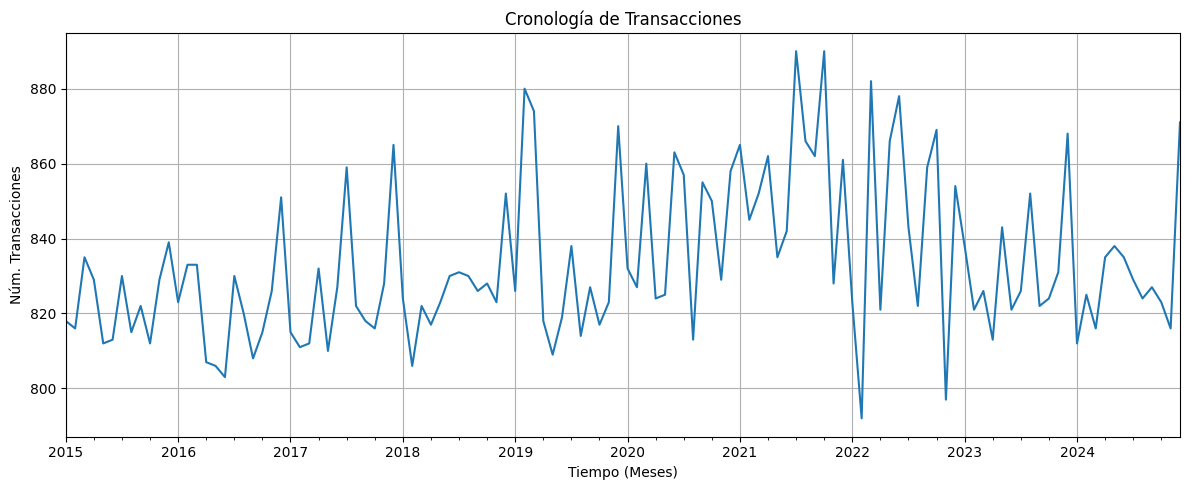

In [ ]:
# Gráfico de línias (número de transactions por meses)
df_transactions.set_index('transaction_time').resample('ME').size().plot(
    kind='line',
    figsize=(12, 5),
    title='Cronología de Transacciones',
    xlabel='Tiempo (Meses)',
    ylabel='Núm. Transacciones'
)

plt.grid(True)
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Según vemos en el gráfico, el volumen de transacciones presenta cierta estacionalidad a lo largo de los meses. Hay algunos meses (por ejemplo, a finales de cada año) donde se presentan picos de transacciones. También observo que a parte de los picos y caídas en el número de transacciones, vemos una evolución a lo largo del tiempo en que va creciendo el número máximo de transacciones (a final del 2021 es el máximo global), hasta estabilizarse un poco entre los años 2022 y 2025.

### ALTERNATIVA CON IA

Prompt:

Given the dataframe df_transactions,
what visualizations would you suggest using the Pandas library
in order to study the chronology of the number of transactions over time?

Respuesta IA:

You've already created a great monthly view of transactions.
To further analyze the chronology, you could visualize the daily number of transactions.
This might reveal shorter-term trends or patterns.

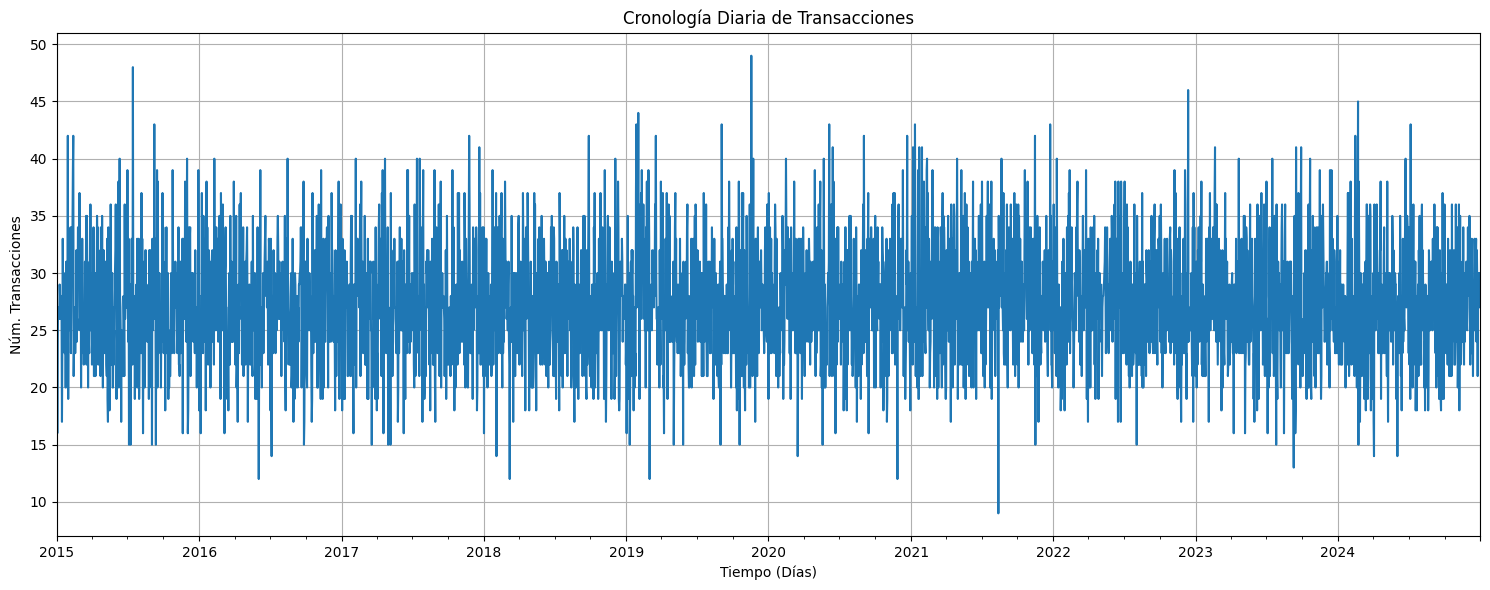

In [ ]:
# Gráfico de líneas (número de transactions por día)
df_transactions.set_index('transaction_time').resample('D').size().plot(
    kind='line',
    figsize=(15, 6),
    title='Cronología Diaria de Transacciones',
    xlabel='Tiempo (Días)',
    ylabel='Núm. Transacciones'
)
plt.grid(True)
plt.tight_layout()
plt.show()

VALORACIÓN COMPARATIVA:

Comparando los dos gráficos, a pesar de que el gráfico diario proporciona un detalle más fino que la vista mensual, yo optaría definiivamente por la vista mensual puesto que si vamos al detalle de los días es difícil apreciar una tendencia temporal del número de transacciones ya que a nivel diario los datos estan demasiado granularizados y no se ve mucha diferencia entre cada periodo. Quizás sería interesante ver el detalle por días escogiendo un periodo global más corto, como por ejemplo un solo año en concreto.

### 1.1.2: Usuarios con mayor Facturación

- Dataframe: *df_transactions*
- Columnas: *user_id, amount, declined*
- Gráfico de Barras (con Seaborn), *user_id / sum(amount)*

In [9]:
# DataFrame top usuarios
df_top_users = (
    df_transactions[df_transactions['declined'] == 0]
    .groupby('user_id')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

display(df_top_users)

,user_id,amount
0,289,47332.90
1,318,46393.44
2,455,40594.55
3,417,37393.91
4,185,34560.87
5,285,33217.28
6,454,29528.42
7,349,27835.38
8,193,27076.83
9,317,22484.76


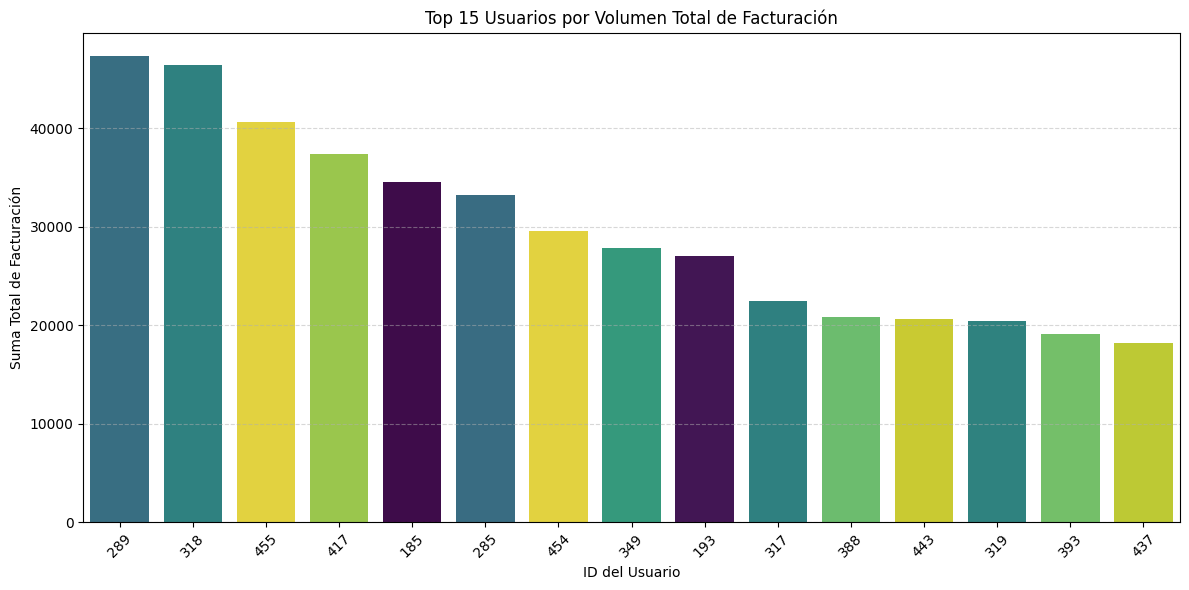

In [ ]:
# Configuración del gráfico
plt.figure(figsize=(12, 6))

# Gráfico con Seaborn
sns.barplot(
    data=df_top_users,
    x='user_id',
    y='amount',
    palette='viridis',
    hue='user_id',
    legend=False,
    order=df_top_users['user_id']
)

# Detalles estéticos (Matplotlib)
plt.title('Top 15 Usuarios por Volumen Total de Facturación')
plt.xlabel('ID del Usuario')
plt.ylabel('Suma Total de Facturación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Podemos ver que todos los 15 usuarios con mayor facturación se mueven aproximadamente entre los niveles de 20k y 40k dólares, con tres usuarios muy destacados que alcanzan más del doble que el mínimo, llegando a una facturación de más de 40.000 $ en total (son los usuarios: 289, 318 y 455).

### ALTERNATIVA CON IA

Para los top usuarios por facturación, un gráfico horizontal puede ofrecer una perspectiva más limpia.

Prompt:

Partiendo de la tabla df_transactions, haz un gráfico alternativo al que yo he hecho, mediante Seaborn, donde se puede apreciar bien a los top usuarios (user_id) ordenados por su mayor número de facturación (sum(amount))

Respuesta IA:

¡Claro! Una excelente alternativa usando Seaborn es un gráfico de barras horizontales. Este formato suele ser más fácil de leer cuando comparamos muchos IDs o categorías, ya que permite ver claramente los valores y las etiquetas. He reutilizado tu DataFrame df_top_users para mantener la consistencia.

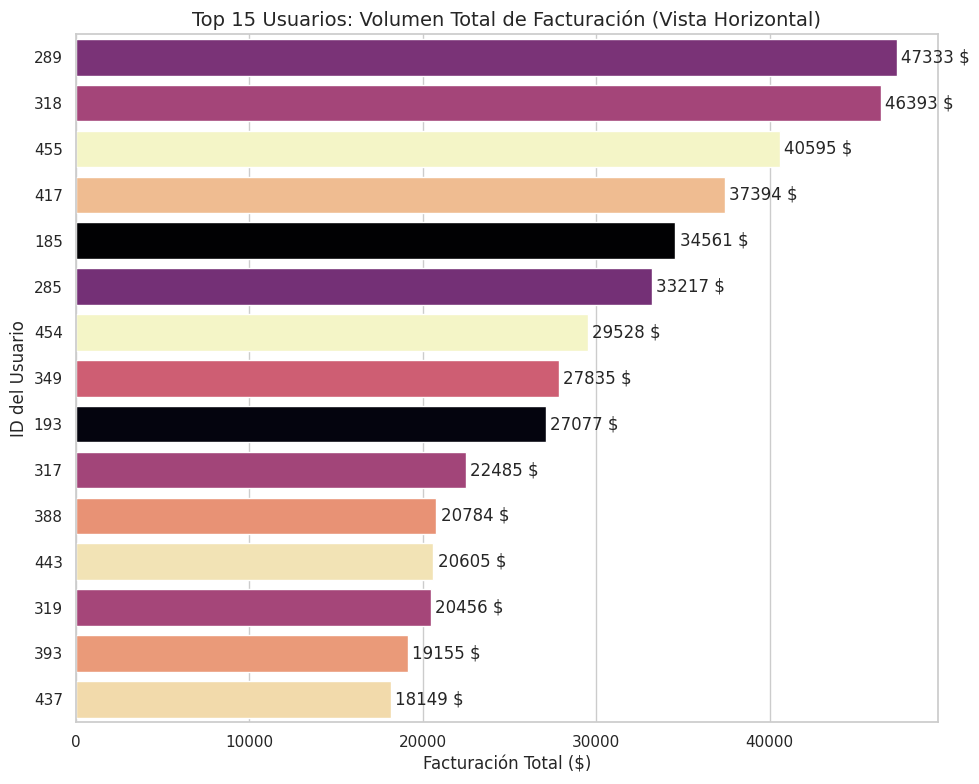

In [ ]:
# Configuración estética de Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Creación del gráfico horizontal
plot = sns.barplot(
    data=df_top_users,
    y=df_top_users['user_id'].astype(str),  # Convertimos a string para que Seaborn lo trate como categoría
    x='amount',
    palette='magma',
    hue='user_id',
    legend=False
)

# Añadir etiquetas de valor al final de cada barra para mayor claridad
for container in plot.containers:
    plot.bar_label(container, fmt='%.0f $', padding=3)

plt.title('Top 15 Usuarios: Volumen Total de Facturación (Vista Horizontal)', fontsize=14)
plt.xlabel('Facturación Total ($)')
plt.ylabel('ID del Usuario')

plt.tight_layout()
plt.show()

IA: Al usar un gráfico horizontal y añadir etiquetas de datos directamente en las barras, facilitamos la comparación directa sin tener que forzar la vista hacia el eje X. Se confirma visualmente la dominancia de los usuarios 289 y 318.

VALORACIÓN COMPARATIVA:

Ciertamente acepto como buena la sugerencia de la IA de usar un gráfico en de barras en formato horizontal, puesto que así se aprecian mejor los top usuarios. También a nivel estético, ha sido buena sugerencia incorporar los valores totales de facturación para cada usuario.

### 1.1.3: Distribución horaria de Transacciones

- Dataframe: *df_transactions*
- Columnas: *transaction_time, amount, declined*
- Gráfico Violinplot (de Seaborn)

In [10]:
# Nueva columna con hora de las transacciones
df_transactions['transaction_hour'] = df_transactions['transaction_time'].dt.hour
display(df_transactions[['transaction_time', 'transaction_hour', 'amount']].head())

,transaction_time,transaction_hour,amount
0,2022-09-21 22:52:27,22,328.77
1,2022-05-20 08:36:18,8,767.03
2,2021-01-18 20:41:16,20,579.65
3,2024-10-07 16:43:17,16,133.63
4,2024-01-15 20:18:34,20,250.61


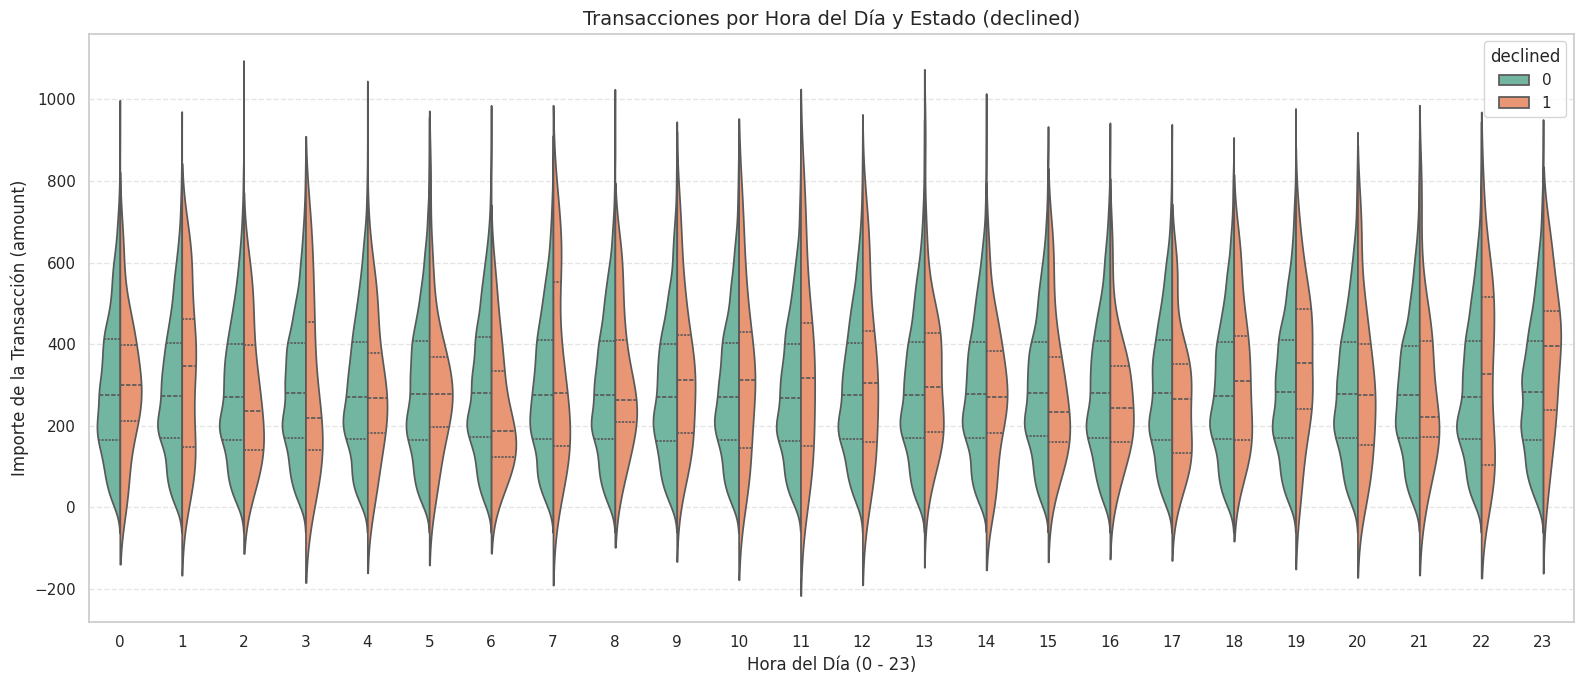

In [ ]:
# Gráfico de violín (violin plot)
plt.figure(figsize=(16, 7))

sns.violinplot(
    data=df_transactions,
    x='transaction_hour',
    y='amount',
    hue='declined',
    split=True,
    inner='quartile',
    palette='Set2'
)

# Detalles visuales i etiquetas
plt.title('Transacciones por Hora del Día y Estado (declined)', fontsize=14)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Importe de la Transacción (amount)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
display(df_transactions['amount'].describe())

,amount
count,100000.000000
mean,292.954743
std,167.014332
min,1.960000
25%,167.947500
50%,275.960000
75%,406.340000
max,1032.150000


INTERPRETACIÓN:

No se aprecian grandes diferencias en la distribución de las transacciones a lo largo del día, puesto que vemos que los valores de las transacciones para cada hora se situan alrededor de la mediana global de 275$ y en unos rangos bastante parecidos. Quizás como detalle concreto a destacar, podemos ver como en las horas cercanas a medianoche (23:00, 0:00 y 1:00) hay un valor mediano mayor de las transacciones rechazadas. Valdría la pena investigar cuáles son las razones de las transacciones rechazadas en este horario.

In [11]:
filtro_rechazadas = df_transactions['declined'] == 1
filtro_hora = df_transactions['transaction_hour'].isin([23, 0, 1])

df_rechazadas_globales = df_transactions[filtro_rechazadas]
df_rechazadas_nocturnas = df_transactions[filtro_rechazadas & filtro_hora]

# display(df_rechazadas_globales['decline_reason'].value_counts())
# display(df_rechazadas_nocturnas['decline_reason'].value_counts())

pct_globales = (df_rechazadas_globales['decline_reason'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
display(pct_globales)

pct_nocturnas = (df_rechazadas_nocturnas['decline_reason'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
display(pct_nocturnas)

,proportion
decline_reason,
insufficient_funds,31.53%
suspected_fraud,23.65%
limit_exceeded,16.1%
technical_error,15.65%
expired_card,13.06%


,proportion
decline_reason,
insufficient_funds,36.72%
suspected_fraud,22.66%
technical_error,15.62%
limit_exceeded,13.28%
expired_card,11.72%


Curiosamente, vemos como las razones principales de las transacciones rechazadas en este horario nocturno son intentos de pago con fondos insuficientes o intentos de fraude, más que no problemas técnicos. Pero estas razones tampoco son significativas en este horario concreto sino que son coherentes con las razones a nivel global de todas las transacciones.

### ALTERNATIVA CON IA

### Boxplot Comparativo por Horas

Un gráfico de cajas permite observar con mayor precisión la dispersión y los valores extremos en cada franja horaria.

Prompt:

Necesito analizar la distribución del amount de las transacciones a lo largo de las horas del día. También debemos comparar su comportamiento según si las transacciones son aceptadas o rechazadas. Construye un gráfico alternativo adecuado usando Seaborn para poder visualizar todo esto.

Respuesta IA:

Para ofrecer una perspectiva alternativa al gráfico de violín, podemos utilizar un boxplot (diagrama de caja). Mientras que el gráfico de violín muestra la densidad completa, el boxplot es excelente para identificar rápidamente medianas, cuartiles y valores atípicos (outliers) de forma más limpia cuando comparamos 24 horas distintas.

He generado el gráfico de cajas (boxplot) como alternativa al gráfico de violín. Esta visualización permite identificar con mayor claridad los valores atípicos (puntos negros) y comparar los rangos intercuartílicos de las transacciones aceptadas frente a las rechazadas para cada hora del día de manera más limpia.

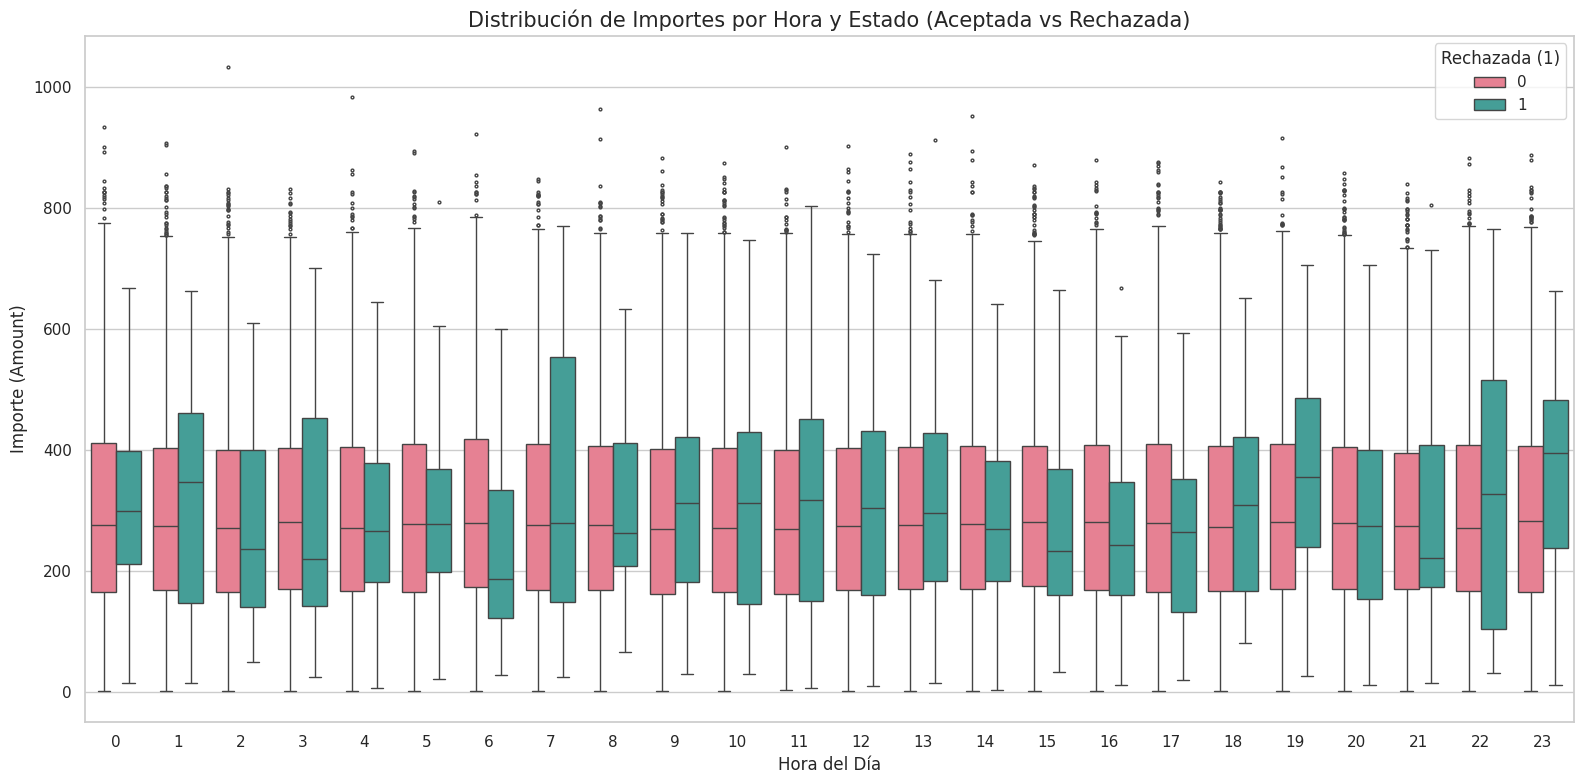

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

# Creación del Boxplot
sns.boxplot(
    data=df_transactions,
    x='transaction_hour',
    y='amount',
    hue='declined',
    palette='husl',
    fliersize=2  # Tamaño de los puntos atípicos
)

# Personalización
plt.title('Distribución de Importes por Hora y Estado (Aceptada vs Rechazada)', fontsize=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Importe (Amount)', fontsize=12)
plt.legend(title='Rechazada (1)', loc='upper right')

plt.tight_layout()
plt.show()

VALORACIÓN COMPARATIVA:

Ciertamente la opción del boxplot como gráfico para ver la distribución de transacciones a lo largo de las horas me parece una muy buena opción. Creo que así se aprecian mejor los valores medianos y los cuartiles, es decir, el grueso importante del volumen de transacciones, así como también se pueden observar cómo se situan los valores extremos. En este gráfico boxplot, por ejemplo, se puede detectar más fácilmente que las horas 7:00 y 22:00 son las que aparentemente acumulan mayor número de transacciones rechazadas. Lo único que quizás yo cambiaría de este último gráfico sería el código de colores, usando mejor el verde para las transacciones aceptadas y el rojo para las rechazadas.

### 1.1.4: Transacciones por Días de la semana

- Dataframe: *df_transactions*
- Columna: *transaction_time, transaction_day_name*
- Gráfico: Barras verticales (días de la semana)

In [ ]:
display(df_transactions['transaction_time'].dt.day_name().value_counts())

,count
transaction_time,
Thursday,14516
Saturday,14353
Sunday,14289
Wednesday,14272
Friday,14272
Tuesday,14176
Monday,14122


In [ ]:
# Nueva columna transaction_day
dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_transactions['transaction_day'] = pd.Categorical(
    df_transactions['transaction_time'].dt.day_name(),
    categories=dias_semana,
    ordered=True
)

display(df_transactions['transaction_day'].value_counts().sort_index())

,count
transaction_day,
Monday,14122
Tuesday,14176
Wednesday,14272
Thursday,14516
Friday,14272
Saturday,14353
Sunday,14289


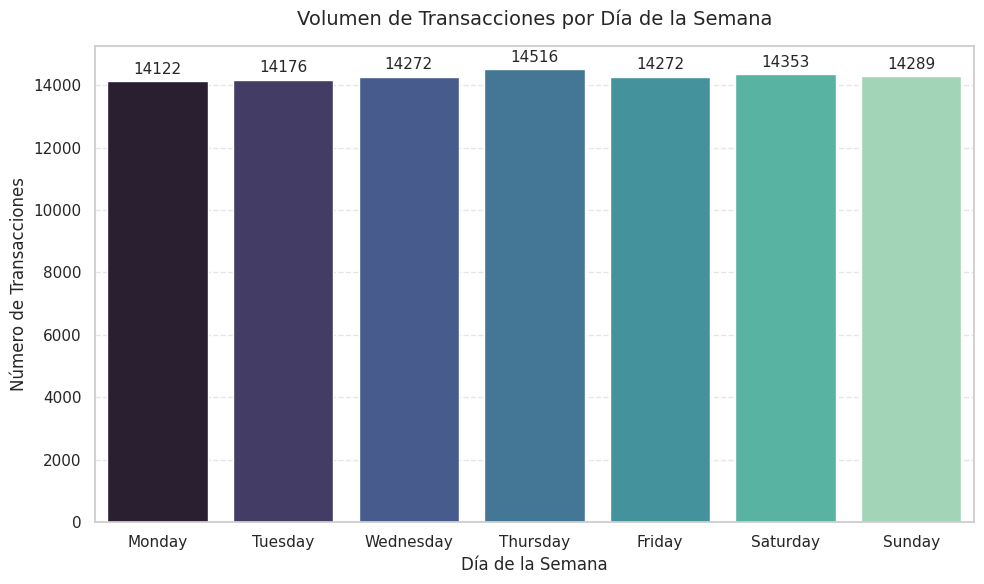

In [ ]:
# Visualización con Gráfico de Barras

# Dataframe auxiliar
df_transacciones_dias = df_transactions['transaction_day'].value_counts().sort_index().reset_index()

# Renombramos las columnas para el gráfico
df_transacciones_dias.columns = ['dia_semana', 'total_transacciones']

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Gráfico de barras verticales con Seaborn
grafico = sns.barplot(
    data=df_transacciones_dias,
    x='dia_semana',
    y='total_transacciones',
    palette='mako',
    hue='dia_semana',
    legend=False
)

# Añadimos los valores en cada barra
for container in grafico.containers:
    grafico.bar_label(container, fmt='%d', padding=3, fontsize=11)

# Detalles visuales con Matplotlib
plt.title('Volumen de Transacciones por Día de la Semana', fontsize=14, pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Número de Transacciones', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Viendo el gráfico con la distribución de las transacciones por días de la semana, podemos decir que es bastante homogénea y es difícil apreciar sólo con la altura de las barras qué día es el más destacado. Por ello, ha sido recomendable añadir las etiquetas con el número exacto para cada barra, y así podemos concluir que el día con mayor volumen es los Jueves.

### ALTERNATIVA CON IA:

### Gráfico Polar de Ciclo Semanal

Para resaltar las pequeñas diferencias entre días y visualizar la naturaleza cíclica de la semana, un gráfico de área polar es una de las opciones más avanzadas y estéticas.

Prompt:

Usando la tabla df_transactions, construye el mejor gráfico posible para ver cómo se distribuyen las transacciones por días de la semana.

Respuesta IA:

Dado que en el gráfico anterior las barras eran muy similares, la mejor alternativa para visualizar ciclos semanales es un Gráfico Polar o de Radar.

Este tipo de visualización permite ver el 'ritmo' de la semana de forma circular, lo que facilita identificar si hay una expansión hacia un día concreto (como los jueves, que mencionaste) de una manera mucho más visual y profesional.

El gráfico polar se ha generado correctamente. Como puedes observar, esta visualización 'circular' resalta mucho mejor la ligera expansión hacia el jueves y el sábado, mostrando el volumen de transacciones como un área que crece o decrece según el día, lo cual es ideal para identificar patrones semanales de forma intuitiva.

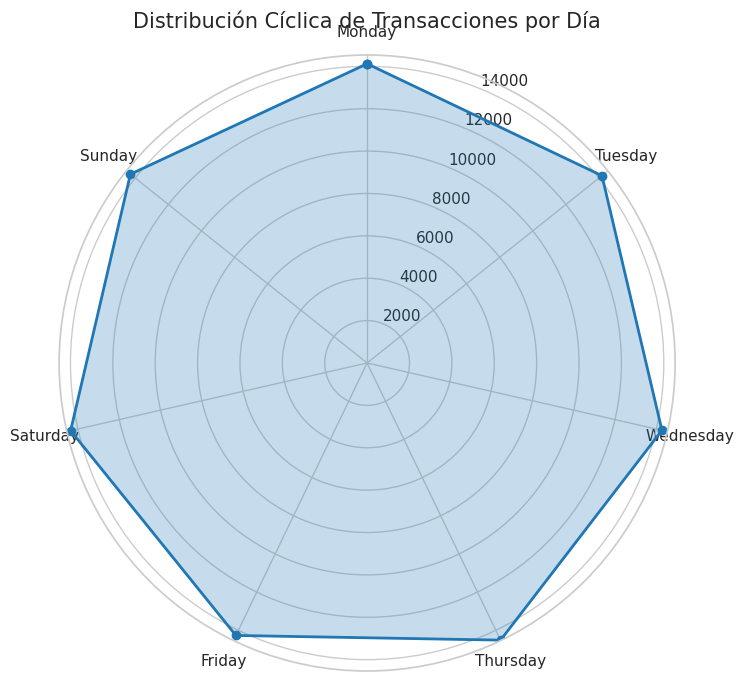

In [ ]:
import numpy as np

# Preparación de datos para el gráfico polar
df_polar = df_transactions['transaction_day'].value_counts().sort_index().reset_index()
df_polar.columns = ['dia', 'total']

# Configuración de ángulos (dividimos el círculo en 7 partes)
num_vars = len(df_polar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# Cerramos el gráfico circular volviendo al inicio
values = df_polar['total'].tolist()
values += values[:1]
angles += angles[:1]

# Creación del gráfico
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Dibujar el área
ax.fill(angles, values, color='#1f77b4', alpha=0.25)
ax.plot(angles, values, color='#1f77b4', linewidth=2, marker='o')

# Etiquetas de los días
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], df_polar['dia'], fontsize=11)

# Título y ajustes
plt.title('Distribución Cíclica de Transacciones por Día', size=15, pad=20)
plt.show()

VALORACIÓN COMPARATIVA:

El gráfico polar puede ser una buena opción para visualizar valores cíclicos como los días de la semana pero sinceramente, en este caso, creo que no nos ha ayudado demasiado a apreciar las particularidades de nuestros datos, más allá de poder concluir que efectivamente la distribución es bastante homogénea.

## Ejercicio 1.2: Preguntas analíticas complejas

En este ejercicio deberemos combinar datos de diferentes tablas para responder a cuestiones más complejas, realizando transformaciones intermedias, agregaciones y funciones (mediante merge, pivot, crosstab...)

### 1.2.1: Hay dependencia de un número reducido de países de las empresas?

Pasos:

1. Combinar la información de transacciones con la de compañías
2. Agrupar la facturación por país
3. Calcular la facturación total generada por cada país
4. Ordenar los países de mayor a menor facturación
5. Calcular el porcentaje acumulado sobre el total
6. Visualizar

In [12]:
# 1. Combinar la información de transacciones con la de compañías
df_transactions_companies = pd.merge(
    df_transactions,
    df_companies,
    left_on='business_id',
    right_on='company_id',
    how='left'
)

display(df_transactions_companies.head())

,transaction_id,card_id,business_id,transaction_time,amount,declined,product_ids,user_id,latitude,longitude,...,distance_km,transaction_hour,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,CcS-4857,b-2378,2022-09-21 22:52:27,328.77,0,"28, 8, 73",276,40.513745,-4.238857,...,46.53,22,b-2378,Erat LLP,+51 502 888 6124,non.vestibulum@protonmail.net,Netherlands,https://www.erat-llp.com,Home,premium
1,6BE556F4-9B3F-4C64-A4E2-237E89269A33,CcS-4857,b-2442,2022-05-20 08:36:18,767.03,0,"14, 39, 65, 27",276,40.031749,-4.169403,...,58.27,8,b-2442,Aliquam Erat Volutpat LLP,+39 372 330 7229,pede.nunc@icloud.net,Italy,https://www.aliquam-erat-volutpat-llp.com,Books,mid-market
2,2C8531E2-AB1C-456F-9A87-BC9390E6AA8C,CcS-4857,b-2466,2021-01-18 20:41:16,579.65,0,"61, 18, 17, 58, 42",276,40.886042,-3.677155,...,52.23,20,b-2466,Amet Lorem LLP,+40 468 847 7738,ultricies.adipiscing@icloud.edu,Spain,https://www.amet-lorem-llp.com,Toys,mid-market
3,B954A0B3-9314-4615-ACBB-B31E0245D8D1,CcS-4857,b-2558,2024-10-07 16:43:17,133.63,0,35,276,40.305523,-3.744586,...,12.85,16,b-2558,Nulla Integer Vulputate Corp.,+75 236 687 9162,interdum@protonmail.org,Sweden,https://www.nulla-integer-vulputate-corp.com,Gaming,premium
4,FD857386-28F9-49DE-8F32-E2458CDE1752,CcS-4857,b-2434,2024-01-15 20:18:34,250.61,0,"48, 54, 23",276,40.961108,-3.961454,...,64.30,20,b-2434,Tristique Neque Venenatis Institute,+18 605 905 7882,ullamcorper.magna@hotmail.ca,Sweden,https://www.tristique-neque-venenatis-institut...,Books,mid-market


In [13]:
# 2. Agrupar la facturación por país
# 3. Calcular la facturación total generada por cada país
# 4. Ordenar los países de mayor a menor facturación
df_transactions_countries = (df_transactions_companies
                             .groupby('country')['amount']
                             .sum()
                             .sort_values(ascending=False)
                             .reset_index())

# 5. Calcular el porcentaje acumulado sobre el total
df_transactions_countries['percent'] = ((df_transactions_countries['amount'] / df_transactions_countries['amount'].sum()) * 100).round(2)

display(df_transactions_countries)

,country,amount,percent
0,Sweden,4928290.24,16.82
1,Netherlands,4506571.38,15.38
2,United Kingdom,4099117.08,13.99
3,Italy,4087557.38,13.95
4,Germany,4020364.07,13.72
5,France,1416084.26,4.83
6,United States,1101737.27,3.76
7,Belgium,952208.75,3.25
8,Norway,809288.82,2.76
9,Ireland,715220.46,2.44


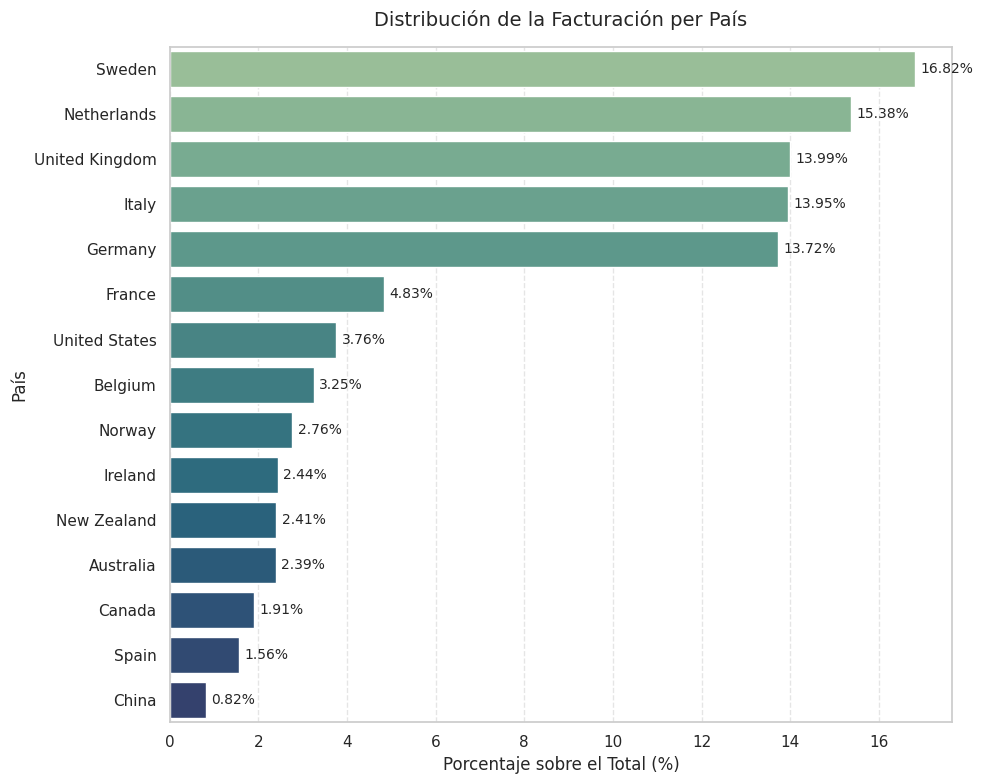

In [ ]:
# 6. Visualizar (Gráfico de Barras horizontales)
plt.figure(figsize=(10, 8))

grafico_paises = sns.barplot(
    data=df_transactions_countries,
    x='percent',
    y='country',
    palette='crest',
    hue='country',
    legend=False
)

for container in grafico_paises.containers:
    grafico_paises.bar_label(container, fmt='%.2f%%', padding=4, fontsize=10)

plt.title('Distribución de la Facturación per País', fontsize=14, pad=15)
plt.xlabel('Porcentaje sobre el Total (%)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Respondiendo a la pregunta sobre si hay dependencia con un número reducido de países, podemos observar que sí que efectivamente el volumen de facturación se concentra en 5 países destacados que acumulan casi el 75% del total. Estos cinco países son: Suecia, Países Bajos, Reino Unido, Italia y Alemania.

### 1.2.2: Existe estacionalidad en las ventas?

Pasos a seguir:

1. Trabajar con los datos de transacciones
2. Extraer la información temporal relevant (año y mes)
3. Calcular el volumen total de ventas (suma de amount) per año y mes
4. Comparar patrones temporales entre años, creando una tabla tipo pivot
5. Visualizar la evolución

In [14]:
# Volumen total de ventas por año y mes
df_transacciones_meses = (
    df_transactions[df_transactions['declined'] == 0]
    # Variable temporal con formato "YYYY-MM"
    .assign(year_month=lambda x: x['transaction_time'].dt.strftime('%Y-%m'))
    # Agrupamos por esta columna year-month
    .groupby('year_month')['amount']
    .sum()
)

display(df_transacciones_meses.head(12))

,amount
year_month,
2015-01,221978.21
2015-02,245780.13
2015-03,253000.65
2015-04,245597.21
2015-05,248585.36
2015-06,232624.35
2015-07,241252.27
2015-08,233797.97
2015-09,227211.93


In [15]:
# Patrones temporales (con pivot table)
df_pivot_meses = (
    df_transactions
    .query("declined == 0")
    .assign(
        year=lambda x: x['transaction_time'].dt.year,
        month=lambda x: x['transaction_time'].dt.month
    )
    .pivot_table(
        values='amount',      # métrica
        index='year',         # filas
        columns='month',      # columnas
        aggfunc='sum',        # Operación (suma)
        fill_value=0,         # valor por defecto
    )
)

display(df_pivot_meses)

/tmp/ipykernel_1546/3721637745.py:4: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("declined == 0")


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2015,221978.21,245780.13,253000.65,245597.21,248585.36,232624.35,241252.27,233797.97,227211.93,241722.74,225568.41,234787.51
2016,224451.27,248112.42,246634.37,240833.04,241306.84,230577.43,237081.73,235600.88,241530.84,250228.07,234831.91,234536.82
2017,222956.21,252303.71,237621.09,251596.72,240125.80,240337.61,240576.35,230225.76,230606.28,240875.48,242562.33,249902.05
2018,227411.90,245092.09,237099.83,234246.30,244448.97,242769.22,231261.73,228759.89,236768.38,253827.42,240049.08,234419.07
2019,222944.11,259807.32,276818.21,242707.81,242550.42,241694.85,233513.25,237070.53,232551.83,250595.22,231857.36,253678.24
2020,231702.95,248318.04,258872.56,244251.90,253699.74,236410.96,240255.64,232658.86,257964.96,258891.46,221821.05,243677.58
2021,243339.85,257434.31,250861.14,259770.51,239662.08,234080.71,251450.91,237051.75,245398.37,264897.72,240242.32,240108.44
2022,224709.53,235427.85,271978.12,237165.49,276262.60,260082.37,233349.01,245198.95,254316.72,256342.46,230435.35,237818.73
2023,228413.66,251422.67,241711.00,241264.06,261355.45,232254.56,238652.72,237981.15,234226.30,250946.37,233083.92,235132.78


In [ ]:
# Valores totales por mes
totales_por_mes = df_pivot_meses.sum().sort_values(ascending=False)
display(totales_por_mes)

,0
month,
10,2522641.40
3,2520388.99
5,2502119.88
2,2493596.61
4,2442202.19
12,2413341.12
6,2395202.87
9,2394802.50
7,2377425.14


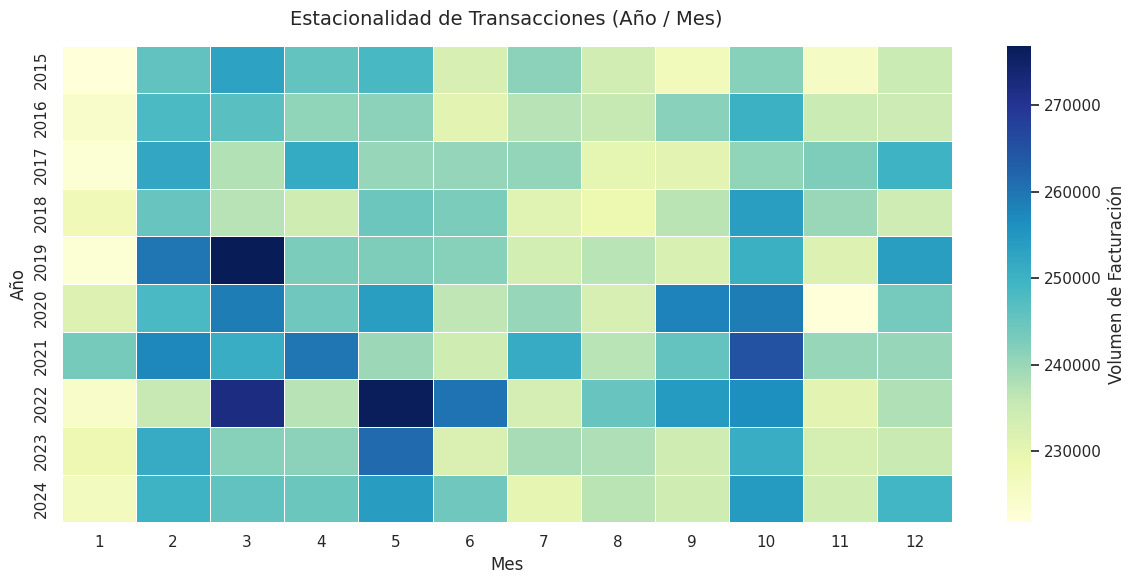

In [ ]:
# Visualización gráfica (mapa de calor)
plt.figure(figsize=(12, 6))

sns.heatmap(
    data=df_pivot_meses,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Volumen de Facturación'}
)

plt.title('Estacionalidad de Transacciones (Año / Mes)', fontsize=14, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Año', fontsize=12)
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Con el mapa de color, podemos ver a simple vista que la facturación presenta efectivamente cierta estacionalidad. Concretamente, vemos que en los meses de Enero y Noviembre es cuando hay menos volumen de facturación, mientras que en Octubre, Marzo y Mayo es cuando hay un mayor volumen. Estos datos que vemos visualmente en el mapa de calor, también podemos confirmar que coinciden con los valores promedio de la facturación total por meses.

### 1.2.3: Análisis de concentración y variabilidad

Qué productos generan más ingresos y con qué variabilidad?

In [16]:
# 1. Tabla auxiliar de transacciones por productos
sql_query = """
SELECT
    t.transaction_id,
    t.transaction_time,
    TRIM(product_id) AS product_id,
    t.amount
FROM
    `sprint9-visuals-jordi-calmet.sprint9_analytics.transactions_clean` AS t,
    UNNEST(SPLIT(t.product_ids, ',')) AS product_id
WHERE
    t.declined = 0
"""

df_transacciones_productos = client.query(sql_query).result().to_dataframe()
display(df_transacciones_productos.head())

,transaction_id,transaction_time,product_id,amount
0,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,2022-09-21 22:52:27+00:00,28,328.77
1,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,2022-09-21 22:52:27+00:00,8,328.77
2,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,2022-09-21 22:52:27+00:00,73,328.77
3,6BE556F4-9B3F-4C64-A4E2-237E89269A33,2022-05-20 08:36:18+00:00,14,767.03
4,6BE556F4-9B3F-4C64-A4E2-237E89269A33,2022-05-20 08:36:18+00:00,39,767.03


In [17]:
# 2. Calcular ingresos por productos
df_ventas_productos = (
    df_transacciones_productos
    .groupby('product_id')['amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'amount': 'total_revenue'})
)

# 3. Seleccionar los 15 primeros
top_15_productos = (
    df_ventas_productos
    .head(15)
    .assign(product_id=lambda x: x['product_id'].astype(str))
)

display(top_15_productos)

,product_id,total_revenue
0,67,1141422.71
1,64,1141124.95
2,39,1140988.17
3,12,1124248.15
4,93,1120366.37
5,15,1118587.59
6,16,1117757.48
7,62,1115537.07
8,86,1106871.50
9,68,1098600.97


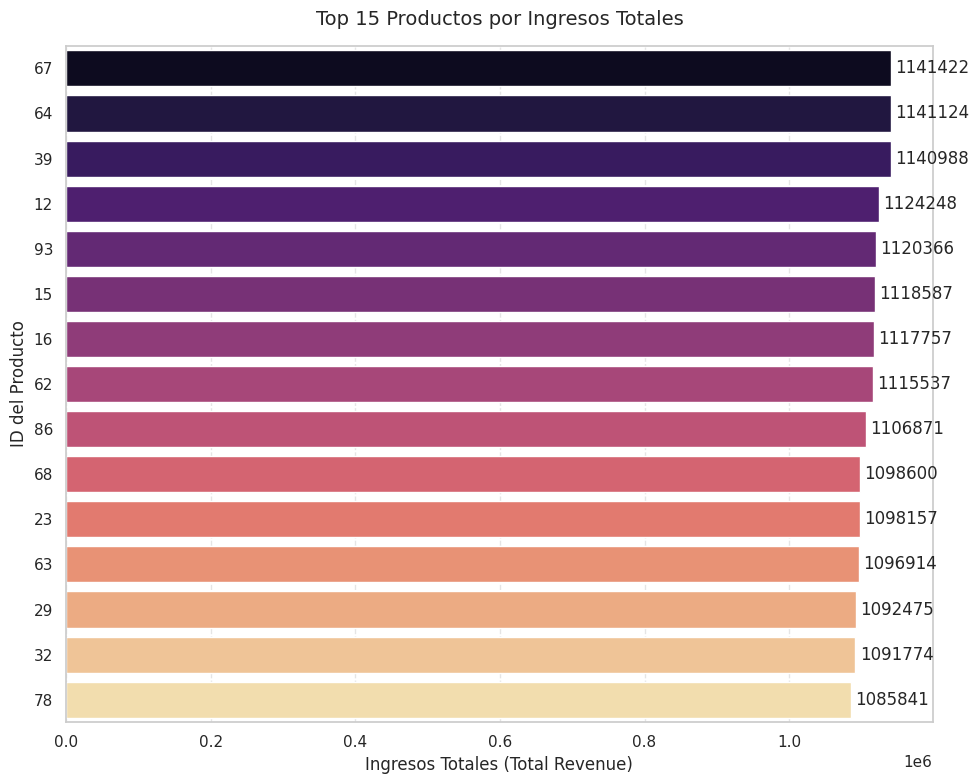

In [ ]:
# Visualización por productos (Gráfico de Barras)

plt.figure(figsize=(10, 8))

grafico_productos = sns.barplot(
    data=top_15_productos,
    x='total_revenue',
    y='product_id',
    palette='magma',
    hue='product_id',
    legend=False
)

for container in grafico_productos.containers:
    grafico_productos.bar_label(container, fmt='%d', padding=3)

plt.title('Top 15 Productos por Ingresos Totales', fontsize=14, pad=15)
plt.xlabel('Ingresos Totales (Total Revenue)', fontsize=12)
plt.ylabel('ID del Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

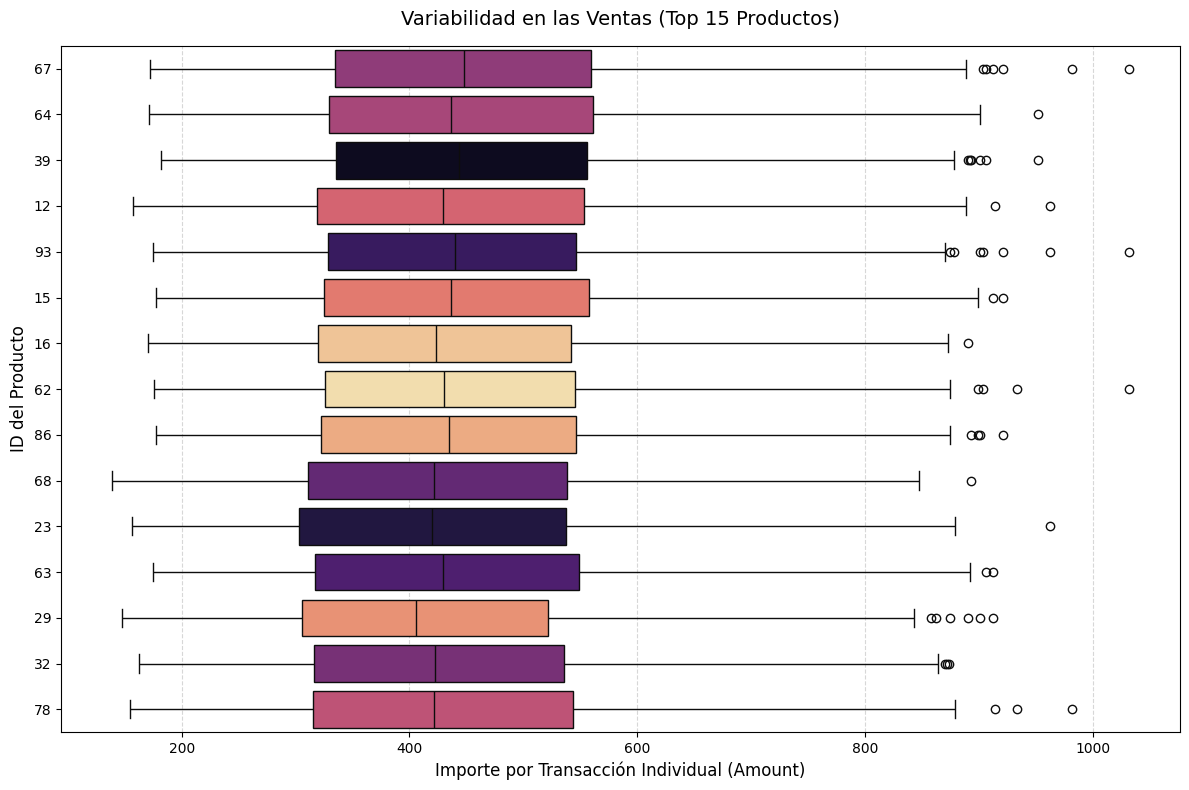

In [18]:
# Visualización de Variabilidad (Boxplot)
lista_top_15 = top_15_productos['product_id'].tolist()

df_variabilidad = (
    df_transacciones_productos
    .assign(product_id_str=lambda x: x['product_id'].astype(str))
    .query("product_id_str in @lista_top_15")
)

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df_variabilidad,
    x='amount',
    y='product_id_str',
    palette='magma',
    hue='product_id_str',
    legend=False,
    order=lista_top_15
)

plt.title('Variabilidad en las Ventas (Top 15 Productos)', fontsize=14, pad=15)
plt.xlabel('Importe por Transacción Individual (Amount)', fontsize=12)
plt.ylabel('ID del Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Métrica exacta de variabilidad
df_metrica_variabilidad = (
    df_variabilidad
    .groupby('product_id_str')['amount']
    .agg(
        mediana='mean',
        desviacion_standard='std'
    )
    .assign(
        coeficiente_variacion_pct=lambda x: (x['desviacion_standard'] / x['mediana']) * 100
    )
    .sort_values('coeficiente_variacion_pct', ascending=False)
    .assign(
        mediana=lambda x: x['mediana'].round(2),
        desviacion_standard=lambda x: x['desviacion_standard'].round(2),
        coeficiente_variacion_pct=lambda x: x['coeficiente_variacion_pct'].round(2)
    )
)

display(df_metrica_variabilidad)

,mediana,desviacion_standard,coeficiente_variacion_pct
product_id_str,,,
23,427.63,159.01,37.18
12,444.19,161.64,36.39
29,419.05,149.76,35.74
68,427.80,152.19,35.58
78,432.61,153.04,35.38
32,430.00,148.33,34.49
62,442.50,152.44,34.45
63,438.06,150.50,34.36
16,432.74,148.19,34.24


INTERPRETACIÓN:

Con el gráfico boxplot, podemos hacernos una idea de la variabilidad que presentan estos 15 productos top en sus ventas. A simple vista podemos ver que las variabilidades son parecidas para los 15 productos y todos ellos presentan unos valores medios parecidos en cuanto al amount de cada transacción (alrededor de 400 dólares), con algunos valores extremos (outliers) que pueden llegar a 1000$. Para poder hilar más fino, he hecho un cálculo exacto del coeficiente de variabilidad, y todos los valores se situan alrededor del 35%, con un producto destacado que es el id=23 con coeficiente de variabilidad del 37%. Estos valores, al ser menores al 50%, se pueden considerar de una variabilidad moderada.

Esto significa que no hay una gran dispersión de valores en el importe de las transacciones donde aparecen los productos más vendidos.

Pero cabe tener en cuenta que es difícil diferenciar el aporte exacto de cada producto en cada cesta de la compra, puesto que a pesar de que disponemos de la lista de productos en cada transacción y sus precios individuales, no sabemos la cantidad de unidades exactas de cada producto en cada transacción. Por tanto, este estudio de variabilidad tiene una fiabilidad limitada.

### 1.2.4: Patrones horarios

Cómo varía la actividad de ventas por franjas horarias a lo largo de los años?

In [20]:
# Crear franjas horarias aplicando una función

def obtener_franja_horaria(hora):
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noche'
    else:
        return 'Madrugada'

df_transacciones_franjas = (
    df_transactions
    .assign(
        franja_horaria=lambda x: x['transaction_time'].dt.hour.apply(obtener_franja_horaria)
    )
)

display(df_transacciones_franjas[['transaction_time', 'franja_horaria']].head())

,transaction_time,franja_horaria
0,2022-09-21 22:52:27,Noche
1,2022-05-20 08:36:18,Mañana
2,2021-01-18 20:41:16,Noche
3,2024-10-07 16:43:17,Tarde
4,2024-01-15 20:18:34,Noche


In [21]:
# Construir una tabla agregada mediante crosstab
df_transacciones_franjas = df_transacciones_franjas.assign(
    year=lambda x: x['transaction_time'].dt.year
)

df_crosstab_franjas = pd.crosstab(
    index=df_transacciones_franjas['year'],
    columns=df_transacciones_franjas['franja_horaria'],
    margins=True,
    margins_name='Total'
)

display(df_crosstab_franjas[['Madrugada', 'Mañana', 'Tarde', 'Noche']])

franja_horaria,Madrugada,Mañana,Tarde,Noche
year,,,,
2015,2452,2461,2457,2500
2016,2474,2481,2510,2390
2017,2444,2476,2554,2441
2018,2523,2425,2508,2456
2019,2467,2554,2544,2450
2020,2615,2471,2472,2535
2021,2589,2584,2593,2532
2022,2569,2457,2520,2560
2023,2516,2551,2464,2454


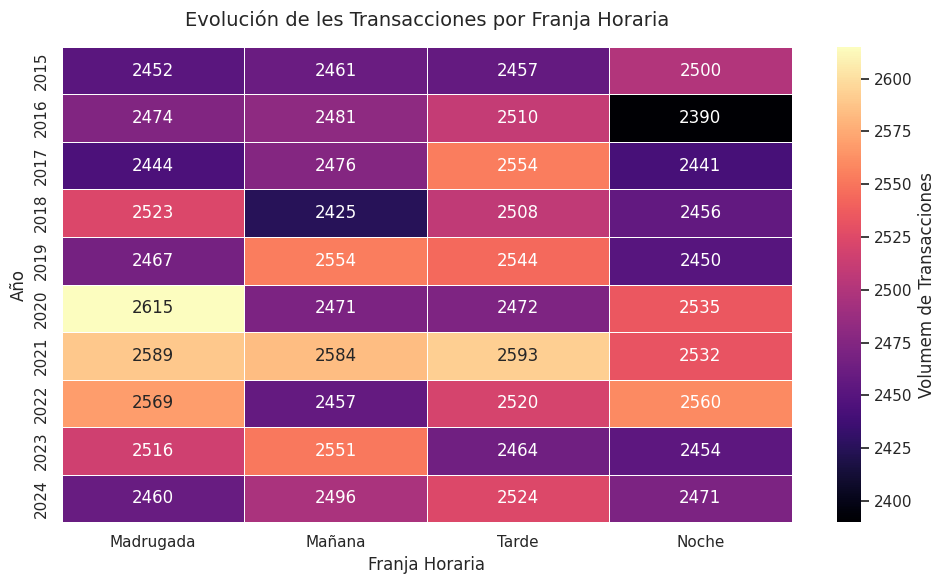

In [ ]:
# Visualitzar con un Mapa de Calor (Heatmap)

df_heatmap_horarios = (
    df_crosstab_franjas
    .drop('Total', axis=0)
    .drop('Total', axis=1)
    [['Madrugada', 'Mañana', 'Tarde', 'Noche']]
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    data=df_heatmap_horarios,
    cmap='magma',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={'label': 'Volumem de Transacciones'}
)

plt.title('Evolución de les Transacciones por Franja Horaria', fontsize=14, pad=15)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Año', fontsize=12)
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

Vemos en el mapa de calor cómo se distribuye el volumen de transacciones por franjas horarias y a lo largo de los años. No se aprecian grandes contrastes en los valores, pero como conclusión podemos afirmar que las franjas de Tarde y de Madrugada son las que acumulan mayor actividad.

## Nivel 2: Análisis Relacional y Patrones avanzados

## Ejercicio 2.1: Análisis de Productos y Captación de Usuarios

En este ejercicio deberemos analizar el rendimiento de los productos y detectar posibles riesgos de negocio asociados a una concentración excesiva de ingresos, dependencia de usuarios recurrentes o manca de crecimiento en la base de usuarios.

In [22]:
# Tabla con transacciones, tipo de usuarios y productos
sql_query = """
WITH TransaccionesOrdenadas AS (
    SELECT
        t.transaction_id,
        t.user_id,
        t.transaction_time,
        t.amount,
        t.product_ids,
        ROW_NUMBER() OVER(PARTITION BY t.user_id ORDER BY t.transaction_time ASC) as numero_compra
    FROM
        `sprint9-visuals-jordi-calmet.sprint9_analytics.transactions_clean` AS t
    WHERE
        t.declined = 0
)

SELECT
    to_ord.transaction_id,
    to_ord.user_id,
    to_ord.transaction_time,
    TRIM(product_id) AS product_id,
    to_ord.amount,
    (to_ord.numero_compra = 1) AS nuevo_usuario
FROM
    TransaccionesOrdenadas AS to_ord,
    UNNEST(SPLIT(to_ord.product_ids, ',')) AS product_id
"""

df_ventas_info = client.query(sql_query).result().to_dataframe()
display(df_ventas_info.head())

,transaction_id,user_id,transaction_time,product_id,amount,nuevo_usuario
0,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,6,362.99,True
1,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,82,362.99,True
2,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,93,362.99,True
3,BDE62570-005C-4F2F-B55C-E04C00CE26C0,95,2015-01-14 17:08:16+00:00,29,536.29,False
4,BDE62570-005C-4F2F-B55C-E04C00CE26C0,95,2015-01-14 17:08:16+00:00,68,536.29,False


In [23]:
# Merge con información de los productos
df_products = df_products.assign(product_id=lambda x: x['product_id'].astype(str))

df_ventas_info = (
    df_ventas_info
    .assign(product_id=lambda x: x['product_id'].astype(str))
    .merge(
        df_products[['product_id', 'name', 'price', 'category', 'brand']],
        on='product_id',
        how='left'
    )
)

display(df_ventas_info.head())

,transaction_id,user_id,transaction_time,product_id,amount,nuevo_usuario,name,price,category,brand
0,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,6,362.99,True,dooku solo,136.60,Home,NordHaus
1,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,82,362.99,True,kingsblood Littlefinger the,12.45,Toys,MiniWorld
2,4B9A7634-51EC-46CF-A394-843CE778141D,95,2015-01-03 20:07:16+00:00,93,362.99,True,Littlefinger Tarly Stark,192.60,Food,FreshBox
3,BDE62570-005C-4F2F-B55C-E04C00CE26C0,95,2015-01-14 17:08:16+00:00,29,536.29,False,Tully maester Tarly,167.20,Books,PageWorks
4,BDE62570-005C-4F2F-B55C-E04C00CE26C0,95,2015-01-14 17:08:16+00:00,68,536.29,False,Stark Karstark,167.37,Food,Daily Pantry


In [24]:
# Análisis de productos

df_productos_info = (
    df_ventas_info
    .groupby(['product_id', 'name'])
    .agg(
        ingresos_totales=('amount', 'sum'),
        media_amount=('amount', 'mean'),
        desviacion_amount=('amount', 'std'),
        num_nuevos_usuarios=('nuevo_usuario', 'sum'),  # Suma los True (1)
        total_compradores=('nuevo_usuario', 'count')
    )
    # Cálculo de las Métricas
    .assign(
        variabilidad_ingresos=lambda x: (x['desviacion_amount'] / x['media_amount']) * 100,
        pct_nuevos_usuarios=lambda x: (x['num_nuevos_usuarios'] / x['total_compradores']) * 100
    )
    # Filtramos las columnas
    [['ingresos_totales', 'variabilidad_ingresos', 'num_nuevos_usuarios', 'pct_nuevos_usuarios']]
    # Ordenamos por ventas
    .sort_values(by='ingresos_totales', ascending=False)
    .reset_index()
    .assign(
        variabilidad_ingresos=lambda x: x['variabilidad_ingresos'].round(2),
        pct_nuevos_usuarios=lambda x: x['pct_nuevos_usuarios'].round(2)
    )
)

display(df_productos_info.head(10))

,product_id,name,ingresos_totales,variabilidad_ingresos,num_nuevos_usuarios,pct_nuevos_usuarios
0,67,Winterfell,1141422.71,33.11,120,4.75
1,64,Direwolf,1141124.95,33.98,118,4.64
2,39,warden,1140988.17,32.80,120,4.72
3,12,duel Direwolf,1124248.15,36.39,127,5.02
4,93,Littlefinger Tarly Stark,1120366.37,33.75,109,4.33
5,15,Stannis warden,1118587.59,33.91,124,4.95
6,16,the duel warden,1117757.48,34.24,130,5.03
7,62,the duel,1115537.07,34.45,106,4.2
8,86,Stark kingsblood,1106871.50,33.95,110,4.39
9,68,Stark Karstark,1098600.97,35.58,127,4.95


In [ ]:
# Tipologia analítica de productos

ref_ingresos = df_productos_info['ingresos_totales'].median()
ref_captacion = df_productos_info['pct_nuevos_usuarios'].median()

df_productos_info = (
    df_productos_info
    .assign(
        tipologia=lambda x: np.select(
            condlist=[
                # Captador: Ingresos altos y Captación alta
                (x['ingresos_totales'] >= ref_ingresos) & (x['pct_nuevos_usuarios'] >= ref_captacion),
                # Recurrente: Ingresos altos y Captació baja
                (x['ingresos_totales'] >= ref_ingresos) & (x['pct_nuevos_usuarios'] < ref_captacion),
                # Emergente: Ingresos bajos y Captació alta
                (x['ingresos_totales'] < ref_ingresos) & (x['pct_nuevos_usuarios'] >= ref_captacion),
                # Estancado: Ingresos bajos y Captación baja
                (x['ingresos_totales'] < ref_ingresos) & (x['pct_nuevos_usuarios'] < ref_captacion)
            ],
            choicelist=[
                'Captador',
                'Recurrente',
                'Emergente',
                'Estancado'
            ],
            default='Indefinido'
        )
    )
)

display(df_productos_info['tipologia'].value_counts())

,count
tipologia,
Recurrente,29
Emergente,29
Captador,21
Estancado,21


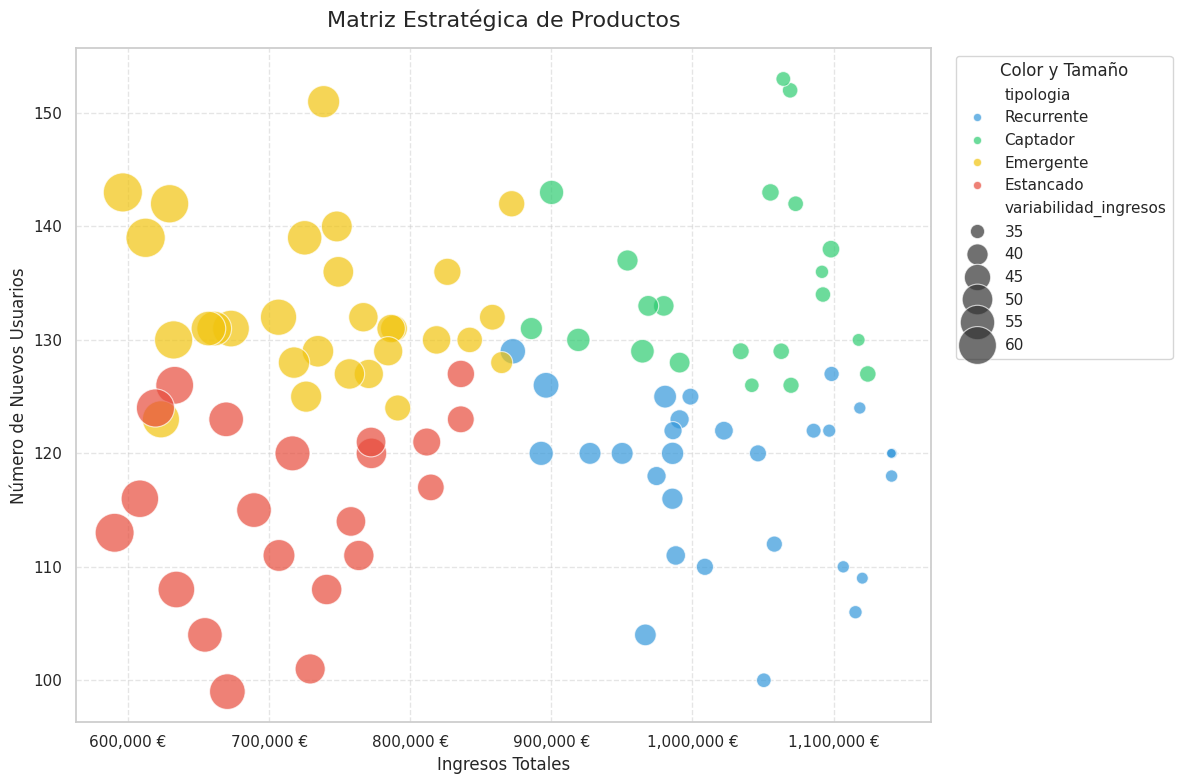

In [ ]:
# Visualización mediante Scatterplot

plt.figure(figsize=(12, 8))

# 2. Definim una paleta de colors personalitzada i amb sentit de negoci
colores = {
    'Captador': '#2ecc71',   # Verde (muchas ventas y muchos usuarios)
    'Recurrente': '#3498db',  # Azul (Fidelidad, ventas aseguradas)
    'Emergente': '#f1c40f',   # Amarillo (Potencial a explotar)
    'Estancado': '#e74c3c',   # Rojo (Atención requerida)
    'Indefinido': '#95a5a6'   # Gris (Default)
}

# 3. Creem el Scatter Plot màgic
sns.scatterplot(
    data=df_productos_info,
    x='ingresos_totales',
    y='num_nuevos_usuarios',
    hue='tipologia',              # Color según la categoría
    size='variabilidad_ingresos', # Tamaño de la burbuja según el riesgo/variabilidad
    sizes=(50, 800),              # Rango de tamaños: de 50 (min)a 800 (max)
    alpha=0.7,                    # Transparencia de las burbujas
    palette=colores
)

plt.title('Matriz Estratégica de Productos', fontsize=16, pad=15)
plt.xlabel('Ingresos Totales', fontsize=12)
plt.ylabel('Número de Nuevos Usuarios', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Color y Tamaño')
plt.tight_layout()

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f} €'))
plt.show()

INTERPRETACIÓN:

En este gráfico se puede observar muy bien como los productos 'Captadores', los que consiguen atraer a nuevos compradores y que generan mayor cantidad de ingresos, son los que más nos interesan. Vemos que estos en general tienen poca variabilidad (burbujas pequeñas) lo que significa que sus ventas son estables y dan una base de confianza para el negocio. En cambio, vemos que los productos emergentes, los que también atraen a nuevos clientes pero no generan tantos ingresos, presentan una variabilidad mayor (burbujas más grandes) y esto quiere decir que son ventas más erráticas, quizás grandes compras pero muy puntuales, y por ello no son tan fiables para el negocio.

Así pues, la prioridad absoluta son los productos Captadores (parte alta y derecha de la tabla) porqué generan muchos ingresos y además hacen ganar compradores, pero también nos interesa mantener los productos Recurrentes (abajo a la derecha) que también generan muchos ingresos de forma estable.

## Ejercicio 2.2: Análisis geográfica y oportunidades de expansión

En este ejercicio, analizaremos el flujo de compra entre los países de las empresas vendedoras y los países de los clientes.

In [25]:
# Tabla de datos

df_flujo_paises = (
    df_transactions
    .assign(
        business_id=lambda x: x['business_id'].astype(str),
        user_id=lambda x: x['user_id'].astype(str)
    )

    # Añadimos info de empresas
    .merge(
        df_companies
        .assign(company_id=lambda x: x['company_id'].astype(str))
        [['company_id', 'country']],

        left_on='business_id',
        right_on='company_id',
        how='left'
    )
    .rename(columns={'country': 'company_country'})

    # Añadimos info de usuarios
    .merge(
        df_users
        .assign(user_id=lambda x: x['user_id'].astype(str))
        [['user_id', 'country']],

        on='user_id',
        how='left'
    )
    .rename(columns={'country': 'user_country'})
)

display(df_flujo_paises[['transaction_id', 'amount', 'company_country', 'user_country']].head())

,transaction_id,amount,company_country,user_country
0,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,328.77,Netherlands,Spain
1,6BE556F4-9B3F-4C64-A4E2-237E89269A33,767.03,Italy,Spain
2,2C8531E2-AB1C-456F-9A87-BC9390E6AA8C,579.65,Spain,Spain
3,B954A0B3-9314-4615-ACBB-B31E0245D8D1,133.63,Sweden,Spain
4,FD857386-28F9-49DE-8F32-E2458CDE1752,250.61,Sweden,Spain


In [26]:
# Añadir variable para el análisis: compra_local = True/False

df_flujo_paises = (
    df_flujo_paises
    .assign(
        compra_local=lambda x: np.where(
            x['company_country'] == x['user_country'], True, False
        ))
)

display(df_flujo_paises[['transaction_id', 'amount', 'company_country', 'user_country', 'compra_local']].head())

,transaction_id,amount,company_country,user_country,compra_local
0,BBCF25B8-420E-4EAE-83C0-F222CB7F5863,328.77,Netherlands,Spain,False
1,6BE556F4-9B3F-4C64-A4E2-237E89269A33,767.03,Italy,Spain,False
2,2C8531E2-AB1C-456F-9A87-BC9390E6AA8C,579.65,Spain,Spain,True
3,B954A0B3-9314-4615-ACBB-B31E0245D8D1,133.63,Sweden,Spain,False
4,FD857386-28F9-49DE-8F32-E2458CDE1752,250.61,Sweden,Spain,False


### Análisis del comportamiento global

- Porcentaje de transacciones locales vs internacionales
- Porcentaje de facturación local vs internacional

In [27]:
# Análisis del comportamiento global

df_analisis_flujo_global = (
    df_flujo_paises
    .groupby('compra_local')
    .agg(
        total_transacciones=('transaction_id', 'count'),
        facturacion_total=('amount', 'sum')
    )
    .assign(
        pct_transacciones=lambda x: (x['total_transacciones'] / x['total_transacciones'].sum()) * 100,
        pct_facturacion=lambda x: (x['facturacion_total'] / x['facturacion_total'].sum()) * 100
    )
    .reset_index()
    .assign(
        tipo_mercado=lambda x: np.where(x['compra_local'], 'Local', 'Internacional')
    )
    [['tipo_mercado', 'total_transacciones', 'pct_transacciones', 'facturacion_total', 'pct_facturacion']]
    .assign(
        pct_transacciones=lambda x: x['pct_transacciones'].round(2),
        pct_facturacion=lambda x: x['pct_facturacion'].round(2),
        facturacion_total=lambda x: x['facturacion_total'].round(2)
    )
)

display(df_analisis_flujo_global)

,tipo_mercado,total_transacciones,pct_transacciones,facturacion_total,pct_facturacion
0,Internacional,88138,88.14,25818782.08,88.13
1,Local,11862,11.86,3476692.27,11.87


### Análisis por país de compra

Para cada país del usuario:

- Porcentaje de compras a empresas del mismo país
- Porcentaje de compras a empresas extranjeras
- Importe total comprado

In [28]:
# Análisis por país de compra
df_analisis_paises_compras = (
    df_flujo_paises
    .groupby('user_country')
    .agg(
        importe_total_compras=('amount', 'sum'),
        proporcion_local=('compra_local', 'mean')
    )
    .assign(
        pct_compra_local=lambda x: x['proporcion_local'] * 100,
        pct_compra_internacional=lambda x: 100 - (x['proporcion_local'] * 100)
    )
    .reset_index()
    [['user_country', 'pct_compra_local', 'pct_compra_internacional', 'importe_total_compras']]
    .sort_values('importe_total_compras', ascending=False)
    .assign(
        pct_compra_local=lambda x: x['pct_compra_local'].round(2),
        pct_compra_internacional=lambda x: x['pct_compra_internacional'].round(2),
        importe_total_compras=lambda x: x['importe_total_compras'].round(2)
    )
)

display(df_analisis_paises_compras.head(10))

,user_country,pct_compra_local,pct_compra_internacional,importe_total_compras
10,United States,18.54,81.46,3091289.85
9,United Kingdom,17.29,82.71,2838889.37
7,Spain,1.74,98.26,2693566.24
0,Canada,9.71,90.29,2688940.83
4,Netherlands,19.32,80.68,2675165.65
6,Portugal,0.00,100.00,2638023.31
3,Italy,17.10,82.90,2603565.73
2,Germany,16.94,83.06,2573251.67
5,Poland,0.00,100.00,2512973.74
8,Sweden,21.30,78.70,2490810.72


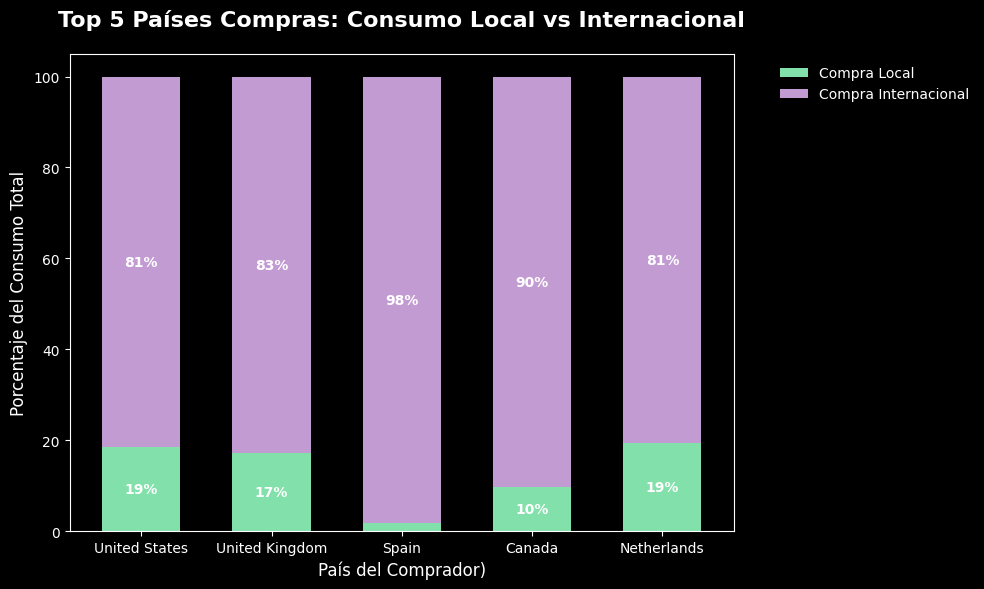

In [29]:
# Visualización por Países Compras (Gráfico de Barras Apiladas)

df_top_compras = df_analisis_paises_compras.head(5)
df_top_compras = (
    df_top_compras
    .set_index('user_country')
    [['pct_compra_local', 'pct_compra_internacional']]
)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

grafico = df_top_compras.plot(
    kind='bar',
    stacked=True,
    color=['#82E0AA', '#C39BD3'],
    width=0.6,
    ax=plt.gca()
)

for p in grafico.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 5:
        grafico.text(
            x + width / 2,
            y + height / 2,
            f'{height:.0f}%',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=10
        )

plt.title('Top 5 Países Compras: Consumo Local vs Internacional', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('País del Comprador)', fontsize=12)
plt.ylabel('Porcentaje del Consumo Total', fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    ['Compra Local', 'Compra Internacional'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)
plt.tight_layout()
plt.show()


### Análisis por país de venta

Para cada país de las empresas que venden, calcular qué parte de su facturación viene de:

- Usuarios locales
- Usuarios internacionales

In [30]:
# Análisis por país de venta

df_analisis_paises_ventas = (
    df_flujo_paises
    .groupby('company_country')
    .agg(
        importe_total_ventas=('amount', 'sum'),
        total_usuarios=('transaction_id', 'count'),
        usuarios_locales=('compra_local', 'sum'),
        proporcion_local=('compra_local', 'mean')
    )
    .assign(
        usuarios_internacionales=lambda x: x['total_usuarios'] - x['usuarios_locales'],
        pct_venta_local=lambda x: x['proporcion_local'] * 100,
        pct_venta_internacional=lambda x: 100 - (x['proporcion_local'] * 100)
    )
    .reset_index()
    .sort_values('importe_total_ventas', ascending=False)
    [['company_country', 'importe_total_ventas',
    'pct_venta_local', 'pct_venta_internacional',
    'usuarios_locales', 'usuarios_internacionales']]
    .assign(
        importe_total_ventas=lambda x: x['importe_total_ventas'].round(2),
        pct_venta_local=lambda x: x['pct_venta_local'].round(2),
        pct_venta_internacional=lambda x: x['pct_venta_internacional'].round(2),
    )
)

display(df_analisis_paises_ventas.head(10))

,company_country,importe_total_ventas,pct_venta_local,pct_venta_internacional,usuarios_locales,usuarios_internacionales
12,Sweden,4928290.24,10.47,89.53,1729,14784
8,Netherlands,4506571.38,11.50,88.50,1731,13324
13,United Kingdom,4099117.08,12.11,87.89,1668,12108
7,Italy,4087557.38,10.72,89.28,1465,12203
5,Germany,4020364.07,11.12,88.88,1478,11813
4,France,1416084.26,11.36,88.64,534,4166
14,United States,1101737.27,52.80,47.20,2131,1905
1,Belgium,952208.75,0.00,100.00,0,3531
10,Norway,809288.82,0.00,100.00,0,3030
6,Ireland,715220.46,0.00,100.00,0,2659


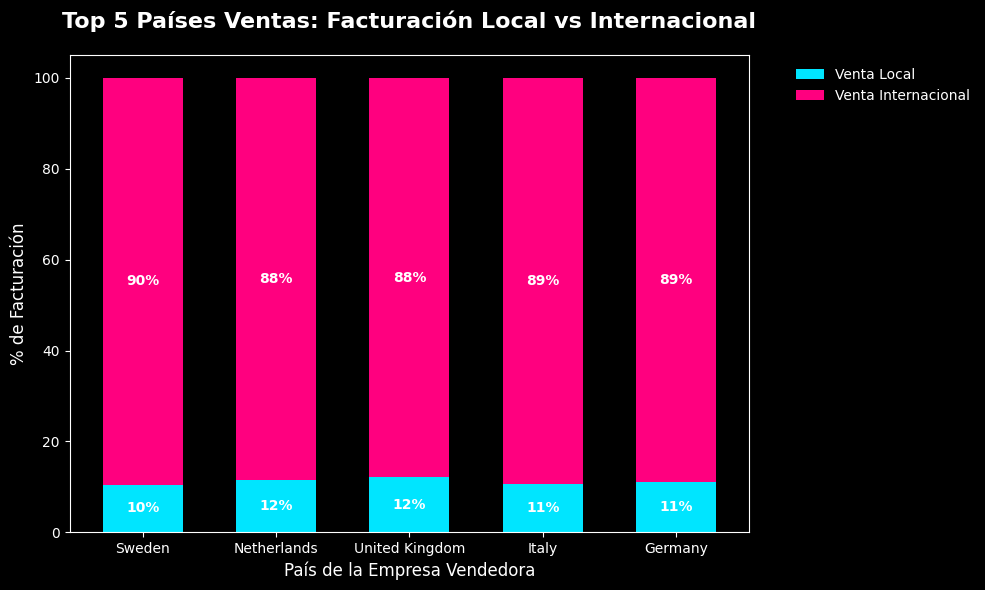

In [31]:
# Visualización Países Ventas (Gráfico de Barras Apiladas)

df_top_ventas = df_analisis_paises_ventas.head(5)
df_top_ventas = df_top_ventas.set_index('company_country')[['pct_venta_local', 'pct_venta_internacional']]

plt.style.use('dark_background') # plt.style.use('default')
plt.figure(figsize=(10, 6))

# Gráfico de barras apiladas des de Pandas
grafico = df_top_ventas.plot(
    kind='bar',
    stacked=True,
    color=['#00E5FF', '#FF007F'],
    width=0.6,
    ax=plt.gca()
)

for p in grafico.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 5:
        grafico.text(
            x + width / 2,
            y + height / 2,
            f'{height:.0f}%',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=10
        )

plt.title('Top 5 Países Ventas: Facturación Local vs Internacional', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('País de la Empresa Vendedora', fontsize=12)
plt.ylabel('% de Facturación', fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    ['Venta Local', 'Venta Internacional'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)
plt.tight_layout()
plt.show()

### INTERPRETACIÓN ESTRATÉGICA

- En qué países valdría la pena abrir más empresas locales?
- Hay países con demanda pero poca oferta local?
- El negocio depende demasiado de empresas de un solo país?
- Abrir empresas locales reduciría la fricción o mejoraría la conversión?

In [32]:
# Demanda (ranking facturación local)
df_demanda_local = (
    df_flujo_paises[df_flujo_paises['compra_local'] == True]
    .groupby('user_country')['amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'amount': 'total_domestic'})
  )

display(df_demanda_local[['user_country', 'total_domestic']].head(10))

,user_country,total_domestic
0,United States,583010.92
1,Sweden,528506.31
2,Netherlands,521393.18
3,United Kingdom,491510.15
4,Germany,447388.07
5,Italy,443472.57
6,Canada,257837.28
7,France,154348.57
8,Spain,49225.22


In [33]:
# Oferta local (número de empresas)
df_companies.groupby('country').size().sort_values(ascending=False).head(10)

,0
country,
Sweden,11
Netherlands,10
United Kingdom,9
Italy,9
United States,9
Germany,8
Belgium,8
Norway,7
Australia,6


In [34]:
df_analisis_flujo_global = (
    df_analisis_flujo_global
    .assign(
        ticket_medio=lambda x: (x['facturacion_total'] / x['total_transacciones']).round(2)
    )
)

display(df_analisis_flujo_global)

,tipo_mercado,total_transacciones,pct_transacciones,facturacion_total,pct_facturacion,ticket_medio
0,Internacional,88138,88.14,25818782.08,88.13,292.94
1,Local,11862,11.86,3476692.27,11.87,293.09


### En qué países valdría la pena abrir más empresas locales?

En base a la tabla de los países con mayor compra local (*df_demanda_local*), vemos de forma destacada que los tres países que tienen más demanda son: Estados Unidos, Suecia y Países Bajos. Por tanto, valdría la pena reforzar la disponibilidad de empresas en estos países para potenciar aún más su actividad.

Por otro lado, en la tabla *df_top_compras* donde hay los países de los usuarios con mayor compra, se puede ver que hay muchos compradores en España y Canadá que basan todas sus compras en el estranjero (más del 90%) y por tanto en estos países también sería interesante abrir más empresas para poder satisfacer mejor su demanda.

### Hay países con demanda pero poca oferta local?

Si miramos los países con más demanda local (*df_demanda_local*) y comparamos esta lista con los países que tienen mayor número de empresas para servir esta demanda, podemos ver cierta discrepancia que valdría la pena considerar. Vemos que el país número uno con más demanda es claramente Estados Unidos y también en el top 5 está Alemania, sin embargo estos dos países no son de los más destacados en la lista de número de empresas. Por tanto, sería recomendable abrir más empresas en Estados Unidos sobretodo y también en Alemania.

### El negocio depende demasiado de empresas de un solo país?

En el ejercicio 1.2.1 ya habíamos estudiado como era la dependencia de la facturación respecto a los países (con la tabla *df_transactions_countries*). Vimos que hay un pequeño grupo de países destacados (Suecia, Países Bajos, Reino Unido, Italia, Alemania) cada uno con alrededor de un 15% de la facturación. Pero no podemos afirmar que haya un solo país que monopolice todo el negocio. En todo caso, sí que podríamos afirmar que el negocio se concentra principalmente en el continente europeo (con casi el 90% de la facturación).

### Abrir empresas locales reduciría la fricción o mejoraría la conversión?

Hemos calculado el valor del ticket medio de las compras (facturacion / num.transacciones) tanto para la actividad doméstica como internacional, y vemos que es un valor muy similar en los dos casos. Esto significa que no se percibe una gran fricción y que los productos tienen una buena implantación a nivel global. A pesar de esto, hacer compras internacionales siempre supone ciertas incomodidades y esfuerzo por parte de los usuarios (coste de aduanas, tiempos de entrega...) y si se ofreciera lo mismo a nivel local seguro que los clientes lo agradecerían y mejoraríamos la conversión.

Por tanto, la estrategia de abrir más locales en los países que hemos valorado con mayor demanda es una muy buena opción.

## Nivel 3: Visualización ejecutiva y storytelling

## Ejercicio 3.1: Mini-dashboard departamental

In [42]:
display(df_flujo_paises.info())
display(df_flujo_paises['decline_reason'].value_counts())
display(df_ventas_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 non-null  object        
 1   card_id           100000 non-null  object        
 2   business_id       100000 non-null  object        
 3   transaction_time  100000 non-null  datetime64[ns]
 4   amount            100000 non-null  float64       
 5   declined          100000 non-null  Int64         
 6   product_ids       100000 non-null  object        
 7   user_id           100000 non-null  object        
 8   latitude          100000 non-null  float64       
 9   longitude         100000 non-null  float64       
 10  discount_amount   100000 non-null  float64       
 11  tax_amount        100000 non-null  float64       
 12  shipping_amount   100000 non-null  float64       
 13  channel           100000 non-null  object        
 14  campa

None

,count
decline_reason,
insufficient_funds,280
suspected_fraud,210
limit_exceeded,143
technical_error,139
expired_card,116


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251084 entries, 0 to 251083
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   transaction_id    251084 non-null  object             
 1   user_id           251084 non-null  Int64              
 2   transaction_time  251084 non-null  datetime64[us, UTC]
 3   product_id        251084 non-null  object             
 4   amount            251084 non-null  float64            
 5   nuevo_usuario     251084 non-null  boolean            
 6   name              251084 non-null  object             
 7   price             251084 non-null  float64            
 8   category          251084 non-null  object             
 9   brand             251084 non-null  object             
dtypes: Int64(1), boolean(1), datetime64[us, UTC](1), float64(2), object(5)
memory usage: 18.0+ MB


None

In [36]:
# Tabla sobre las transacciones rechazadas
df_resumen_declined = (
    df_flujo_paises
    .groupby('declined')
    .agg(
        importe_total=('amount', 'sum'),
        total_transacciones=('amount', 'count')
    )
    .assign(
        pct_transacciones=lambda x: (x['total_transacciones'] / x['total_transacciones'].sum()) * 100,
        pct_facturacion=lambda x: (x['importe_total'] / x['importe_total'].sum()) * 100
    )
    .reset_index()
    .assign(
        estado_transaccion=lambda x: np.where(x['declined'] == 1, 'Declined', 'Accepted'),
        importe_total=lambda x: x['importe_total'].round(2),
        pct_transacciones=lambda x: x['pct_transacciones'].round(2),
        pct_facturacion=lambda x: x['pct_facturacion'].round(2),
        ticket_medio=lambda x: (x['importe_total'] / x['total_transacciones']).round(2)
    )
    [['estado_transaccion', 'total_transacciones',
      'pct_transacciones', 'pct_facturacion',
      'importe_total', 'ticket_medio']]
    .sort_values('total_transacciones', ascending=False)
)

display(df_resumen_declined)

,estado_transaccion,total_transacciones,pct_transacciones,pct_facturacion,importe_total,ticket_medio
0,Accepted,99112,99.11,99.08,29025382.41,292.85
1,Declined,888,0.89,0.92,270091.94,304.16


In [70]:
# Análisis Transacciones Rechazadas (Fraudes o Problemas Técnicos)

# Voy a estudiar los casos de transacciones con posibles fraudes o problemas técnicos
filtro_problematicas = ((df_flujo_paises['declined'] == 1) &
 (df_flujo_paises['decline_reason'].isin(['suspected_fraud', 'technical_error'])))

df_analisis_problematicas = df_flujo_paises[filtro_problematicas]

# Preparamos el dataset para el análisis
df_analisis_problematicas = (
    df_analisis_problematicas
    .assign(user_id=lambda x: x['user_id'].astype(str))
    .merge(
        df_users.assign(user_id=lambda x: x['user_id'].astype(str)),
        on='user_id',
        how='left'
    )
)

df_analisis_problematicas = (
    df_analisis_problematicas
    .assign(
        transaction_day=lambda x: pd.to_datetime(x['transaction_time']).dt.normalize(),
        signup_day=lambda x: pd.to_datetime(x['signup_date']).dt.normalize(),
        antiguedad_dias_usuario=lambda x: (x['transaction_day'] - x['signup_day']).dt.days,
        es_usuario_reciente=lambda x: x['antiguedad_dias_usuario'] <= 90
    )
)

df_analisis_problematicas = (
    df_analisis_problematicas
    .drop(columns=['transaction_hour','latitude', 'longitude',
                   'discount_amount', 'tax_amount', 'shipping_amount',
                   'campaign_id', 'is_international', 'distance_km',
                   'country'])
    .rename(columns={'city': 'user_city', 'address': 'user_address',
                     'email': 'user_email', 'phone': 'user_phone',
                     'region': 'user_region'})
)

df_analisis_problematicas = (
    df_analisis_problematicas
    .assign(
        user_name_surname=lambda x: x['name'] + ' ' + x['surname'],
        birth_date_dt=lambda x: pd.to_datetime(x['birth_date']),
        user_age=lambda x: np.floor((x['transaction_day'] - x['birth_date_dt']).dt.days / 365.25).astype(int)
    )
    .drop(columns=['name', 'surname', 'birth_date_dt'])
)

df_analisis_problematicas = (
    df_analisis_problematicas
    .assign(
        rango_edad=lambda x: pd.cut(
            x['user_age'],
            bins=[0, 15, 39, 59, float('inf')],
            labels=['16-', '16-39', '40-65', '65+']
        )
    )
)

display(df_analisis_problematicas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           349 non-null    object        
 1   card_id                  349 non-null    object        
 2   business_id              349 non-null    object        
 3   transaction_time         349 non-null    datetime64[ns]
 4   amount                   349 non-null    float64       
 5   declined                 349 non-null    Int64         
 6   product_ids              349 non-null    object        
 7   user_id                  349 non-null    object        
 8   channel                  349 non-null    object        
 9   device_type              349 non-null    object        
 10  decline_reason           349 non-null    object        
 11  company_id               349 non-null    object        
 12  company_country          349 non-nul

None

In [87]:
# display(df_analisis_problematicas['es_usuario_reciente'].value_counts())
display(df_analisis_problematicas['user_country'].value_counts())
display(df_analisis_problematicas['rango_edad'].value_counts())
display(df_analisis_problematicas['amount'].describe())

,count
user_country,
Canada,78
United States,71
Spain,31
Poland,26
United Kingdom,23
Portugal,23
Germany,22
Netherlands,22
France,20


,count
rango_edad,
16-39,176
40-65,103
65+,52
16-,18


,amount
count,349.000000
mean,291.281920
std,168.503104
min,3.970000
25%,160.330000
50%,271.560000
75%,410.490000
max,770.030000


In [103]:
# Hay un país que llama la atención de todos los que tienen transacciones problemáticas:
# Poland

# Vamos a estudiarlo detalladamente en nuestro análisis para el dpto. Sistemas
filtro_pais_problematico = df_analisis_problematicas['user_country'] == 'Poland'
df_pais_problematico = df_analisis_problematicas[filtro_pais_problematico]

display(df_pais_problematico['decline_reason'].value_counts())
display(df_pais_problematico['rango_edad'].value_counts())
display(df_pais_problematico['es_usuario_reciente'].value_counts())
display(df_pais_problematico['user_segment'].value_counts())
display(df_pais_problematico['income_band'].value_counts())
display(df_pais_problematico['amount'].describe())

,count
decline_reason,
suspected_fraud,17
technical_error,9


,count
rango_edad,
40-65,11
16-39,10
65+,5
16-,0


,count
es_usuario_reciente,
False,26


,count
user_segment,
occasional,8
family,7
established,6
frequent_shopper,3
young_professional,2


,count
income_band,
medium,15
low,9
high,2


,amount
count,26.000000
mean,314.148462
std,200.210376
min,48.910000
25%,143.955000
50%,251.560000
75%,443.557500
max,770.030000


In [115]:
# Cálculos sobre Transacciones problemáticas
motivos_declined = df_pais_problematico['decline_reason'].value_counts()

importes_declined = (
    df_pais_problematico
    .groupby('decline_reason')['amount']
    .sum()
    .sort_values(ascending=False)
)

edad_motivo_declined = pd.crosstab(
    df_pais_problematico['rango_edad'],
    df_pais_problematico['decline_reason']
)

nivel_motivo_declined = (
    pd.crosstab(
        df_pais_problematico['income_band'],
        df_pais_problematico['decline_reason']
    )
    .reindex(['low', 'medium', 'high'])
    # .loc[lambda x: x.sum(axis=1).sort_values(ascending=False).index]
)

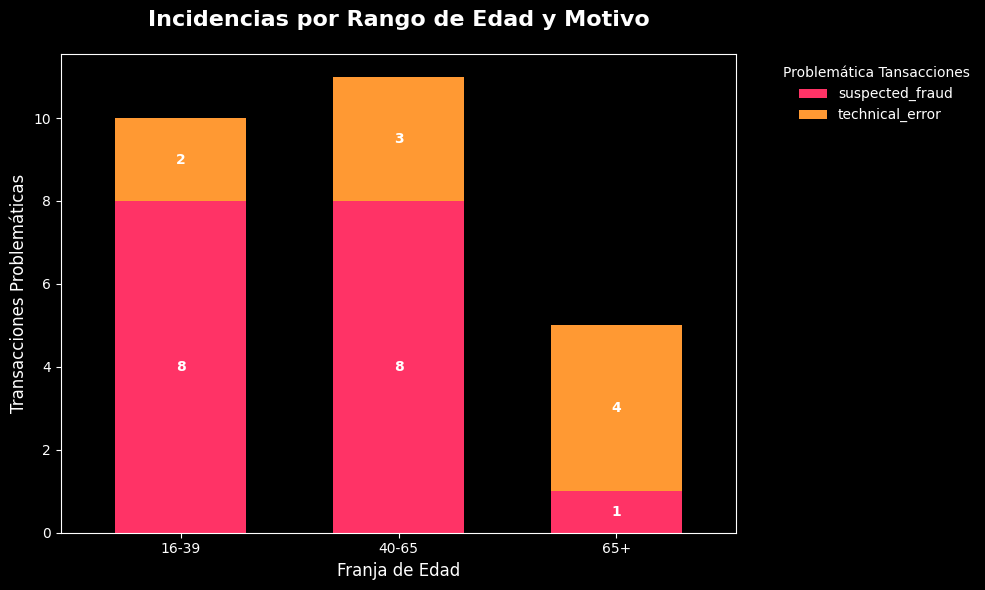

In [109]:
# Visualización Rangos de Edad y Motivos de Fallo

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

ax = edad_motivo_declined.plot(
    kind='bar',
    stacked=True,
    color=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    width=0.6,
    ax=plt.gca()
)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 0:
        ax.text(
            x + width / 2,
            y + height / 2,
            f'{int(height)}',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=10
        )

plt.title('Incidencias por Rango de Edad y Motivo', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Franja de Edad', fontsize=12)
plt.ylabel('Transacciones Problemáticas', fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    title='Problemática Tansacciones',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)
plt.tight_layout()
plt.show()

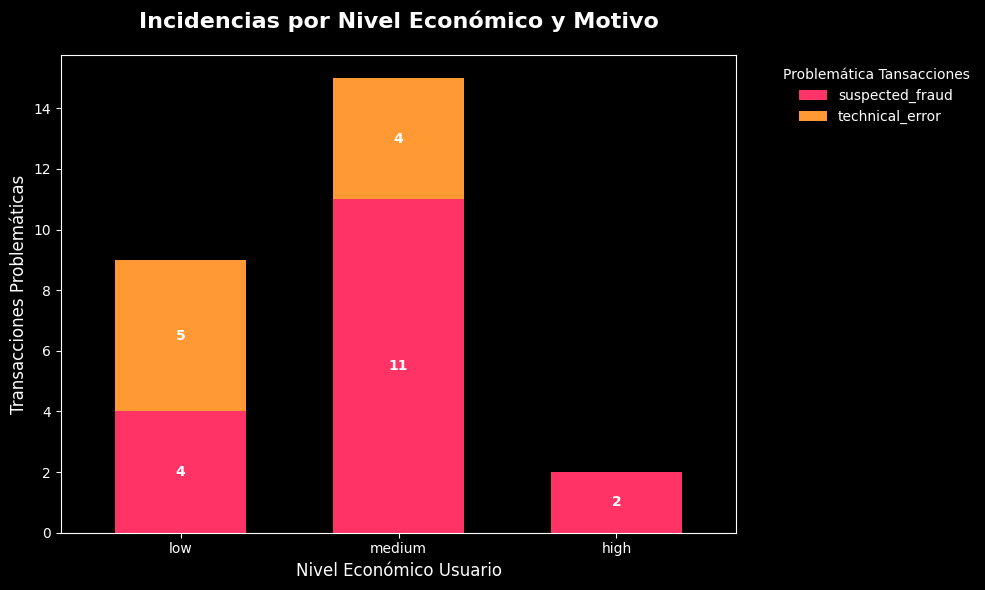

In [116]:
# Visualización Nivel Económico y Motivos de Fallo

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

ax = nivel_motivo_declined.plot(
    kind='bar',
    stacked=True,
    color=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    width=0.6,
    ax=plt.gca()
)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 0:
        ax.text(
            x + width / 2,
            y + height / 2,
            f'{int(height)}',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=10
        )

plt.title('Incidencias por Nivel Económico y Motivo', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Nivel Económico Usuario', fontsize=12)
plt.ylabel('Transacciones Problemáticas', fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    title='Problemática Tansacciones',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)
plt.tight_layout()
plt.show()

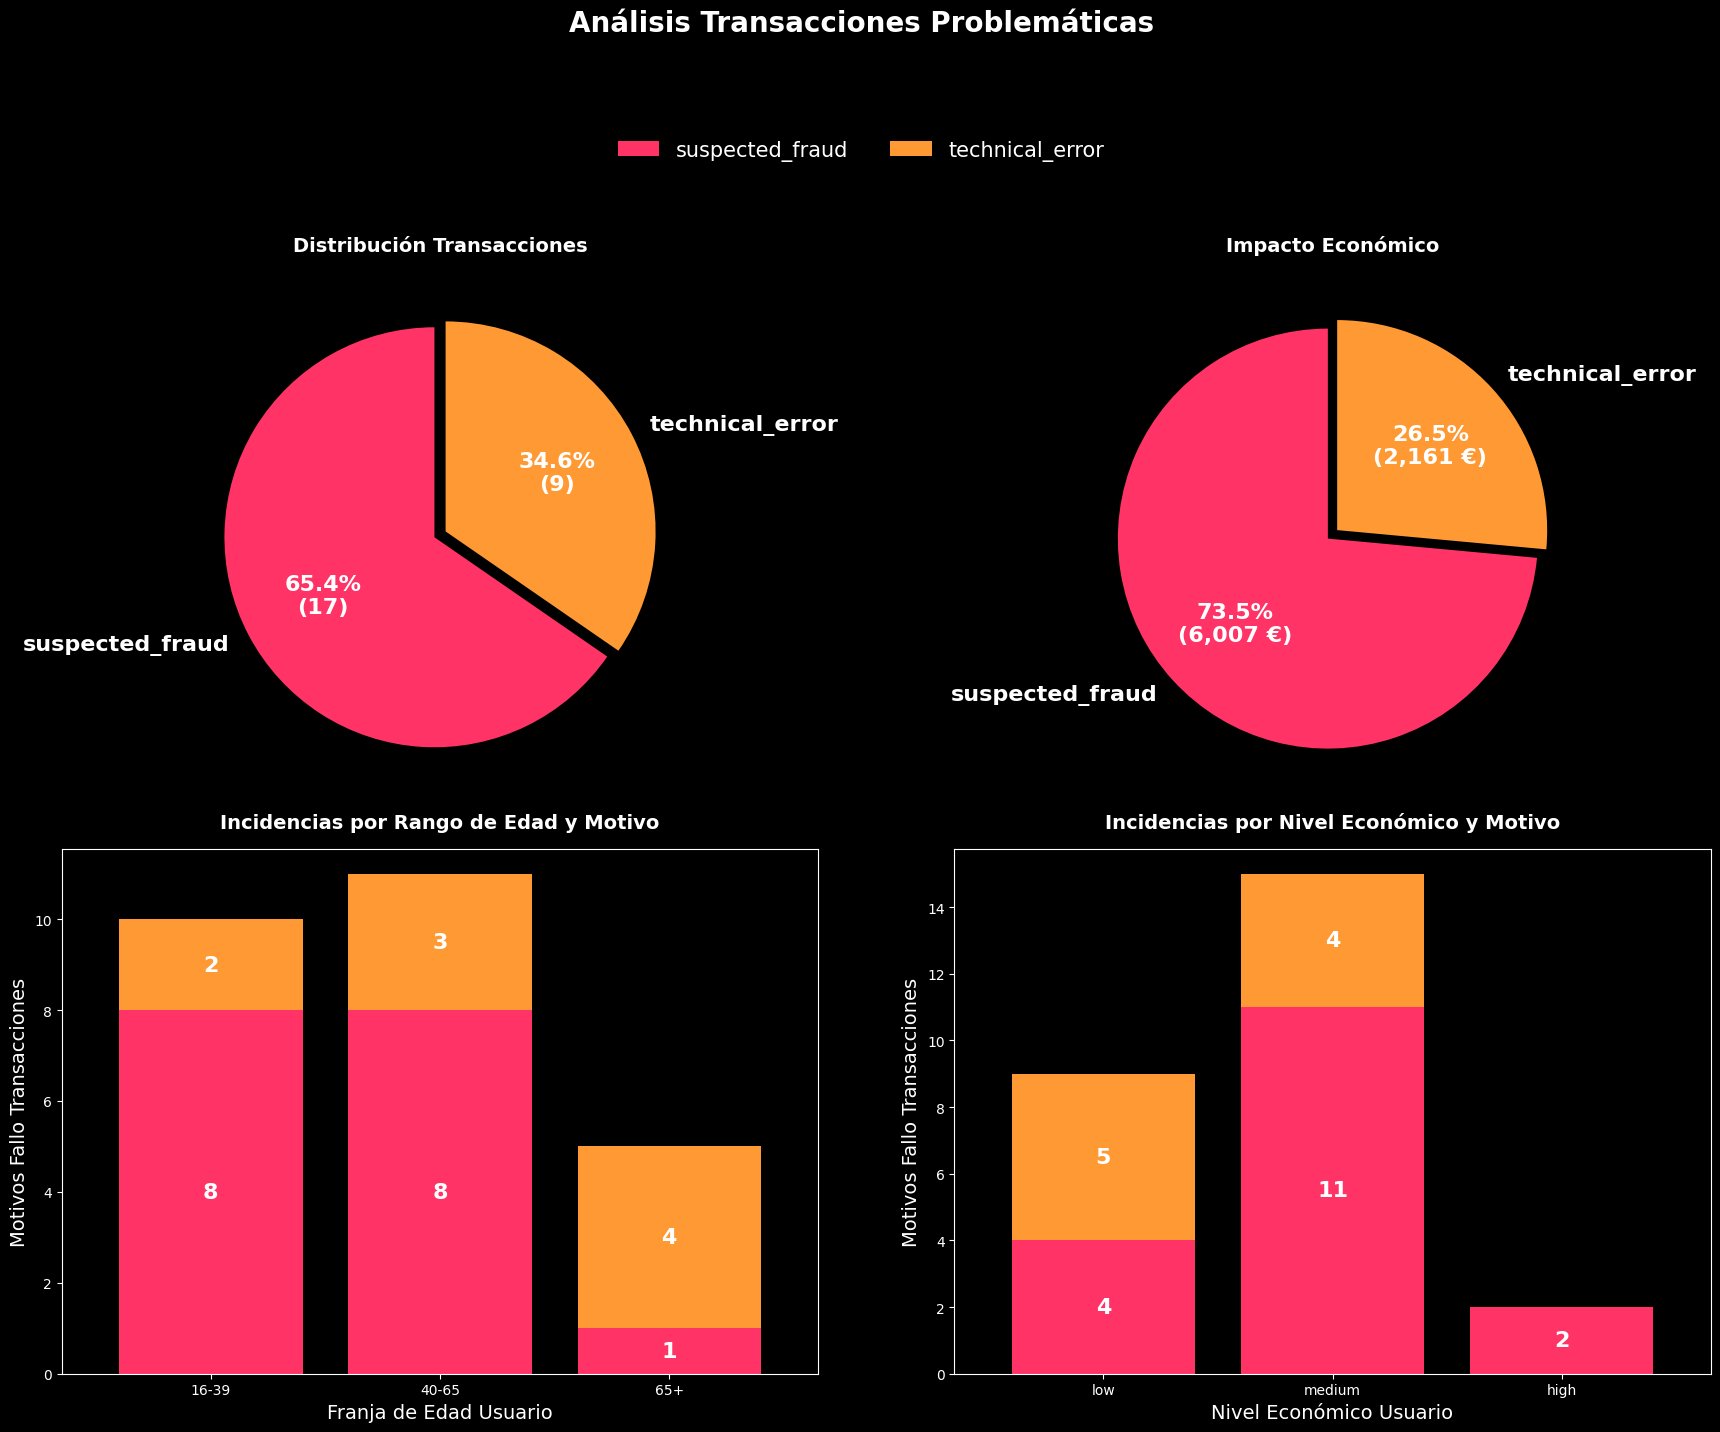

In [135]:
# Mini-dashboard Visualización de Transacciones problemáticas

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- GRÁFICO 1 [0, 0] ---
motivos_declined.plot(
    kind='pie',
    ax=axes[0, 0],
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * motivos_declined.sum() / 100))})',
    startangle=90,
    colors=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    explode=[0.03] * len(motivos_declined),
    ylabel='',
    textprops={'fontsize': 16, 'fontweight': 'bold', 'color': 'white'}
)
axes[0, 0].set_title('Distribución Transacciones', fontsize=14, fontweight='bold', pad=15)

# --- GRÁFICO 2 [0, 1] ---
importes_declined.plot(
    kind='pie',
    ax=axes[0, 1],
    autopct=lambda p: f'{p:.1f}%\n({(p * importes_declined.sum() / 100):,.0f} €)',
    startangle=90,
    colors=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    explode=[0.03] * len(importes_declined),
    ylabel='',
    textprops={'fontsize': 16, 'fontweight': 'bold', 'color': 'white'}
)
axes[0, 1].set_title('Impacto Económico', fontsize=14, fontweight='bold', pad=15)

# --- GRÁFICO 3 [1, 0] ---
edad_motivo_declined.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 0],
    color=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    width=0.8,
    legend=False
)

for p in axes[1, 0].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 0:
        axes[1, 0].text(
            x + width / 2,
            y + height / 2,
            f'{int(height)}',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=16
        )

axes[1, 0].set_title('Incidencias por Rango de Edad y Motivo', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Franja de Edad Usuario', fontsize=14)
axes[1, 0].set_ylabel('Motivos Fallo Transacciones', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=0)

# --- GRÁFICO 4 [1, 1] ---
nivel_motivo_declined.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 1],
    color=['#FF3366', '#FF9933', '#00E5FF', '#B026FF'],
    width=0.8,
    legend=False
)

for p in axes[1, 1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 0:
        axes[1, 1].text(
            x + width / 2,
            y + height / 2,
            f'{int(height)}',
            horizontalalignment='center',
            verticalalignment='center',
            color='white',
            fontweight='bold',
            fontsize=16
        )

axes[1, 1].set_title('Incidencias por Nivel Económico y Motivo', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Nivel Económico Usuario', fontsize=14)
axes[1, 1].set_ylabel('Motivos Fallo Transacciones', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=0)

handles, labels = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.94),
    ncol=4,
    frameon=False,
    fontsize=15
)

plt.suptitle('Análisis Transacciones Problemáticas', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Ejercicio 3.2: Informe ejecutivo